# TP1 - Análisis y Visualización de Datos

Este notebook contiene el análisis exploratorio completo del dataset de ventas, siguiendo las consignas establecidas.

In [1]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
import os
import pyarrow
import pyarrow.parquet as pq
import missingno
import openpyxl
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
from plotly.subplots import make_subplots
import plotly.graph_objects as go

## 1. Carga del Dataset

In [2]:
# Construcción del path relativo al archivo (para que corra en cualquier entorno)
def get_data_path(filename):
    base_dir = os.path.dirname(os.getcwd())
    return os.path.join(base_dir, 'data', filename)


filename = 'sales_data.parquet'


file_path = get_data_path(filename)
raw_df = pd.read_parquet(file_path)


#vemos la estructura del dataset
print(f"Dimensiones: {raw_df.shape}")
print("\nTipos de datos:")
display(raw_df.dtypes)
print("\nValores nulos:")
print(raw_df.isnull().sum().head(52))

Dimensiones: (310217, 52)

Tipos de datos:


factu_codi                      object
factu_nume                       int64
sucur                            int64
fecha                   datetime64[ns]
cliente                          int64
total                          float64
iva1                           float64
lista_precios                    int64
condi_venta                     object
usua                           float64
pedi_codi                       object
pedi_nume                      float64
pedi_sucur                     float64
factu_letra                     object
impor_gravado                  float64
iva_cate                        object
entre_lugar                    float64
entre_fecha             datetime64[ns]
iva_percep                     float64
fecha_regis             datetime64[ns]
conver_alter                   float64
impre_marca                    float64
fecha_alta              datetime64[ns]
host_name_alta                  object
nombre                          object
cuit                     


Valores nulos:
factu_codi                  0
factu_nume                  0
sucur                       0
fecha                       0
cliente                     0
total                       0
iva1                        0
lista_precios               0
condi_venta                 0
usua                      151
pedi_codi                 151
pedi_nume                 151
pedi_sucur                151
factu_letra               151
impor_gravado             151
iva_cate                  151
entre_lugar               151
entre_fecha               151
iva_percep                151
fecha_regis               151
conver_alter              151
impre_marca               151
fecha_alta                151
host_name_alta            151
nombre                      0
cuit                        0
orden_compra_nume       32842
vende                     151
tipo_negocio              151
estado_talon              151
origen_pedido           14621
linea_nume                  0
depo                    

In [3]:
display(raw_df.head())

,factu_codi,factu_nume,sucur,fecha,cliente,total,iva1,lista_precios,condi_venta,usua,pedi_codi,pedi_nume,pedi_sucur,factu_letra,impor_gravado,iva_cate,entre_lugar,entre_fecha,iva_percep,fecha_regis,conver_alter,impre_marca,fecha_alta,host_name_alta,nombre,cuit,orden_compra_nume,vende,tipo_negocio,estado_talon,origen_pedido,linea_nume,depo,produc,canti,precio_uni,boni_porcen,boni_impor,iva1_impor,descrip,iva_percep_porcen,iva_percep_impor,impor_grava,uni_medi,conver,canti_venta,boni_impor_ori,iva_percep_impor_ori,boni_porcen_precio,boni_impor_precio,precio_uni_neto,precio_total
0,fca9,16092,9,2022-01-17,4627,2611.29,453.2,2,00,24.0,pedim,611190.0,9.0,a,2158.09,ri,1.0,2022-01-17,0.0,2022-01-17,1.0,1.0,2022-01-17 16:06:37.890,server,Bautista Benjamin Godoy,27-37333495-4,NaN,1.0,1.0,r,None,2,NaN,000-999-202201370,2000000,716500000.0,0.0,0.0,300930000.0,turron arcor,0,0.0,1.433000e+09,un,1000000,2000000,0.0,0.0,0,0,716500000.0,1.733930e+09
1,fca9,16092,9,2022-01-17,4627,2611.29,453.2,2,00,24.0,pedim,611190.0,9.0,a,2158.09,ri,1.0,2022-01-17,0.0,2022-01-17,1.0,1.0,2022-01-17 16:06:37.890,server,Bautista Benjamin Godoy,27-37333495-4,NaN,1.0,1.0,r,None,3,1.0,000-000-4013,100000000,14330000.0,0.0,0.0,300930000.0,turron x 25g arcor,0,0.0,1.433000e+09,un,1000000,100000000,0.0,0.0,0,0,14330000.0,1.733930e+09
2,fca9,16092,9,2022-01-17,4627,2611.29,453.2,2,00,24.0,pedim,611190.0,9.0,a,2158.09,ri,1.0,2022-01-17,0.0,2022-01-17,1.0,1.0,2022-01-17 16:06:37.890,server,Bautista Benjamin Godoy,27-37333495-4,NaN,1.0,1.0,r,None,1,1.0,000-000-6614,6000000,59734900.0,0.0,0.0,69250000.0,pure tomate arcor x 520,0,0.0,3.297400e+08,un,1000000,6000000,0.0,0.0,8000000,28672800,54956100.0,3.989900e+08
3,fca9,16092,9,2022-01-17,4627,2611.29,453.2,2,00,24.0,pedim,611190.0,9.0,a,2158.09,ri,1.0,2022-01-17,0.0,2022-01-17,1.0,1.0,2022-01-17 16:06:37.890,server,Bautista Benjamin Godoy,27-37333495-4,NaN,1.0,1.0,r,None,4,1.0,000-000-3777,6000000,34403300.0,0.0,0.0,39010000.0,criollitas original x 100 grs.,0,0.0,1.857800e+08,un,1000000,6000000,0.0,0.0,9999900,20641800,30963000.0,2.247900e+08
4,fca9,16092,9,2022-01-17,4627,2611.29,453.2,2,00,24.0,pedim,611190.0,9.0,a,2158.09,ri,1.0,2022-01-17,0.0,2022-01-17,1.0,1.0,2022-01-17 16:06:37.890,server,Bautista Benjamin Godoy,27-37333495-4,NaN,1.0,1.0,r,None,5,1.0,000-000-10204,9000000,102337600.0,0.0,0.0,58030000.0,criollitas x 300 grs,0,0.0,2.763100e+08,di,3000000,3000000,0.0,0.0,10000000,30701400,92103800.0,3.343400e+08


In [4]:
display(raw_df.head(15))

,factu_codi,factu_nume,sucur,fecha,cliente,total,iva1,lista_precios,condi_venta,usua,pedi_codi,pedi_nume,pedi_sucur,factu_letra,impor_gravado,iva_cate,entre_lugar,entre_fecha,iva_percep,fecha_regis,conver_alter,impre_marca,fecha_alta,host_name_alta,nombre,cuit,orden_compra_nume,vende,tipo_negocio,estado_talon,origen_pedido,linea_nume,depo,produc,canti,precio_uni,boni_porcen,boni_impor,iva1_impor,descrip,iva_percep_porcen,iva_percep_impor,impor_grava,uni_medi,conver,canti_venta,boni_impor_ori,iva_percep_impor_ori,boni_porcen_precio,boni_impor_precio,precio_uni_neto,precio_total
0,fca9,16092,9,2022-01-17,4627,2611.29,453.20,2,00,24.0,pedim,611190.0,9.0,a,2158.09,ri,1.0,2022-01-17,0.0,2022-01-17,1.000000,1.0,2022-01-17 16:06:37.890,server,Bautista Benjamin Godoy,27-37333495-4,NaN,1.0,1.0,r,None,2,NaN,000-999-202201370,2000000,716500000.0,0.0,0.0,300930000.0,turron arcor,0,0.0,1.433000e+09,un,1000000,2000000,0.0,0.0,0,0,716500000.0,1.733930e+09
1,fca9,16092,9,2022-01-17,4627,2611.29,453.20,2,00,24.0,pedim,611190.0,9.0,a,2158.09,ri,1.0,2022-01-17,0.0,2022-01-17,1.000000,1.0,2022-01-17 16:06:37.890,server,Bautista Benjamin Godoy,27-37333495-4,NaN,1.0,1.0,r,None,3,1.0,000-000-4013,100000000,14330000.0,0.0,0.0,300930000.0,turron x 25g arcor,0,0.0,1.433000e+09,un,1000000,100000000,0.0,0.0,0,0,14330000.0,1.733930e+09
2,fca9,16092,9,2022-01-17,4627,2611.29,453.20,2,00,24.0,pedim,611190.0,9.0,a,2158.09,ri,1.0,2022-01-17,0.0,2022-01-17,1.000000,1.0,2022-01-17 16:06:37.890,server,Bautista Benjamin Godoy,27-37333495-4,NaN,1.0,1.0,r,None,1,1.0,000-000-6614,6000000,59734900.0,0.0,0.0,69250000.0,pure tomate arcor x 520,0,0.0,3.297400e+08,un,1000000,6000000,0.0,0.0,8000000,28672800,54956100.0,3.989900e+08
3,fca9,16092,9,2022-01-17,4627,2611.29,453.20,2,00,24.0,pedim,611190.0,9.0,a,2158.09,ri,1.0,2022-01-17,0.0,2022-01-17,1.000000,1.0,2022-01-17 16:06:37.890,server,Bautista Benjamin Godoy,27-37333495-4,NaN,1.0,1.0,r,None,4,1.0,000-000-3777,6000000,34403300.0,0.0,0.0,39010000.0,criollitas original x 100 grs.,0,0.0,1.857800e+08,un,1000000,6000000,0.0,0.0,9999900,20641800,30963000.0,2.247900e+08
4,fca9,16092,9,2022-01-17,4627,2611.29,453.20,2,00,24.0,pedim,611190.0,9.0,a,2158.09,ri,1.0,2022-01-17,0.0,2022-01-17,1.000000,1.0,2022-01-17 16:06:37.890,server,Bautista Benjamin Godoy,27-37333495-4,NaN,1.0,1.0,r,None,5,1.0,000-000-10204,9000000,102337600.0,0.0,0.0,58030000.0,criollitas x 300 grs,0,0.0,2.763100e+08,di,3000000,3000000,0.0,0.0,10000000,30701400,92103800.0,3.343400e+08
5,fca9,16226,9,2022-01-28,4627,17909.46,3108.25,2,00,34.0,pedim,614765.0,9.0,a,14801.21,ri,1.0,2022-01-27,0.0,2022-01-28,0.344828,1.0,2022-01-28 10:01:21.027,srvdc902,Bautista Benjamin Godoy,27-37333495-4,NaN,1.0,1.0,r,None,27,1.0,000-000-1060,125000000,672467600.0,0.0,0.0,141220000.0,choco-mani x 120 uds.,0,0.0,6.724700e+08,di,125000000,1000000,0.0,0.0,0,0,672467600.0,8.136900e+08
6,fca9,16226,9,2022-01-28,4627,17909.46,3108.25,2,00,34.0,pedim,614765.0,9.0,a,14801.21,ri,1.0,2022-01-27,0.0,2022-01-28,0.344828,1.0,2022-01-28 10:01:21.027,srvdc902,Bautista Benjamin Godoy,27-37333495-4,NaN,1.0,1.0,r,None,30,1.0,000-000-11809,24000000,233290400.0,0.0,0.0,48990000.0,mr. pops evol. blue berry x 24 uds.,0,0.0,2.332900e+08,di,24000000,1000000,0.0,0.0,0,0,233290400.0,2.822800e+08
7,fca9,16226,9,2022-01-28,4627,17909.46,3108.25,2,00,34.0,pedim,614765.0,9.0,a,14801.21,ri,1.0,2022-01-27,0.0,2022-01-28,0.344828,1.0,2022-01-28 10:01:21.027,srvdc902,Bautista Benjamin Godoy,27-37333495-4,NaN,1.0,1.0,r,None,31,1.0,000-000-11803,24000000,233286700.0,0.0,0.0,48990000.0,mr. pops evol. cherry x 24 uds.,0,0.0,2.332900e+08,di,24000000,1000000,0.0,0.0,0,0,233286700.0,2.822800e+08
8,fca9,16226,9,2022-01-28,4627,17909.46,3108.25,2,00,34.0,pedim,614765.0,9.0,a,14801.21,ri,1.0,2022-01-27,0.0,2022-01-28,0.344828,1.0,2022-01-28 10:01:21.027,srvdc902,Bautista Benjamin Godoy,27-37333495-4,NaN,1.0,1.0,r,None,36,1.0,000-000-5873,14000000,300264200.0,0.0,0.0,63050000.0,flics fruta x 14 uds.,0,0.0,3.002600e+08,di,

### Diccionario de datos


*   **agru\_linea\_nume**: Agrupador auxiliar de línea; suele ser linea\_nume − 1 y es redundante.
    
*   **boni\_impor**: Importe bonificado aplicado al ítem.
    
*   **boni\_impor\_ori**: Importe bonificado original antes de ajustes (redundante con boni\_impor).
    
*   **boni\_impor\_ori\_precio**: Importe bonificado original a nivel precio unitario (redundante con boni\_impor\_precio).
    
*   **boni\_impor\_precio**: Importe bonificado sobre el precio unitario.
    
*   **boni\_porcen**: Porcentaje de bonificación aplicado al producto.
    
*   **boni\_porcen\_precio**: Porcentaje de bonificación aplicado al precio unitario.
    
*   **canti**: Cantidad vendida en la unidad interna del sistema.
    
*   **canti\_venta**: Cantidad expresada en la unidad comercial de venta (correlaciona, pero no siempre 1 : 1, con canti).
    
*   **cliente**: Código único de cliente.
    
*   **condi\_venta**: Condición de venta (00 contado, 07 crédito, _mp_ Mercado Pago, etc.).
    
*   **conver**: Factor de conversión de la unidad de venta a la unidad interna.
    
*   **conver\_alter**: Factor de conversión alternativo.
    
*   **cuit**: CUIT del cliente.
    
*   **depo**: Código del depósito desde donde se despacha el producto.
    
*   **descrip**: Descripción del producto (nombre, peso, presentación).
    
*   **entre\_fecha**: Fecha pactada para la entrega.
    
*   **entre\_lugar**: Código del lugar de entrega (1 retiro / 2 envío).
    
*   **estado\_talon**: Estado del talonario o factura (P pendiente, R registrada, O observada, etc.).
    
*   **factu\_codi**: Código identificador del tipo de factura (p. ej. FEA1, FCA9).
    
*   **factu\_letra**: Letra de la factura (A, B, C).
    
*   **factu\_nume**: Número de factura (identificador único).
    
*   **fecha**: Fecha y hora de emisión de la factura.
    
*   **fecha\_alta**: Fecha y hora en que se dio de alta el registro.
    
*   **fecha\_regis**: Fecha y hora de registro administrativo.
    
*   **host\_name\_alta**: Servidor u hostname donde se creó el registro.
    
*   **impor\_grav**: Importe gravado del ítem (sin impuestos).
    
*   **impor\_gravado**: Importe gravado total a nivel factura.
    
*   **impor\_gravado\_ori**: Importe gravado original (redundante con impor\_gravado).
    
*   **iva1**: Monto de IVA general aplicado sobre el total de la factura.
    
*   **iva1\_impor**: Importe de IVA aplicado al ítem.
    
*   **iva1\_impor\_ori**: IVA original del ítem (redundante con iva1\_impor).
    
*   **iva\_cate**: Categoría de IVA del cliente (RI, RS, CF, etc.).
    
*   **iva\_percep**: Monto de percepciones de IVA en la factura.
    
*   **iva\_percep\_impor**: Percepción de IVA a nivel ítem.
    
*   **iva\_percep\_impor\_ori**: Percepción de IVA original a nivel ítem (redundante con iva\_percep\_impor).
    
*   **iva\_percep\_porcen**: Porcentaje de percepción de IVA aplicada al ítem.
    
*   **linea\_nume**: Número de línea (ítem) dentro de la factura.
    
*   **linea\_nume\_auxi**: Campo auxiliar 1 : 1 con linea\_nume (redundante).
    
*   **lista\_precios**: Código de la lista de precios utilizada.
    
*   **nombre**: Nombre o razón social del cliente.
    
*   **orden\_compra\_nume**: Número de orden de compra del cliente.
    
*   **origen\_pedido**: Origen del pedido (a online, n presencial, t telefónico).
    
*   **pedi\_codi**: Código del tipo de pedido (PEDIE, PEDIM).
    
*   **pedi\_nume**: Número de pedido asociado.
    
*   **pedi\_sucur**: Sucursal donde se emitió el pedido.
    
*   **precio\_total**: Precio total del ítem (precio\_uni\_neto × canti\_venta).
    
*   **precio\_uni**: Precio unitario antes de descuentos e impuestos.
    
*   **precio\_uni\_neto**: Precio unitario neto después de bonificaciones.
    
*   **precio\_uni\_ori**: Precio unitario original (redundante con precio\_uni).
    
*   **produc**: Código de producto (SKU).
    
*   **secuen**: Secuencia interna del dispositivo / línea (1 : 1 con linea\_nume, redundante).
    
*   **sucur**: Código de sucursal (1, 9, 12).
    
*   **tipo\_negocio**: Tipo o canal de negocio (1 retail, 2 mayorista).
    
*   **total**: Importe total de la factura (con impuestos y descuentos).
    
*   **total\_ori**: Total original antes de ajustes (redundante con total).
    
*   **uni\_medi**: Unidad de medida (UN unidad, DI caja, BU peso).
    
*   **usua**: Código del usuario / vendedor.
    
*   **vende**: Código del vendedor asociado.

## 2. Limpieza Básica

### 2.1 Normalización de datos

Cambiamos las magnitudes de las variables cuyas escalas presentan una multiplicación por 1M

In [5]:
df = raw_df.copy()

cols_a_normalizar = [
    'canti',
    'canti_venta',
    'conver',
    'iva1_impor',
    'impor_grava',
    'impor_gravado',
    'precio_uni',
    'precio_uni_neto',
    'precio_total',
    'boni_porcen_precio',
    'boni_impor_precio'	

]

df[cols_a_normalizar] = df[cols_a_normalizar] / 1000000

# #impor_gravado es el producto de dos columnas en millones 
# df['impor_gravado'] = df['impor_gravado'] /1000000000000

display(df.head(2))
# df_prueba=df[df['factu_nume']==16092]
# display(df_prueba)

,factu_codi,factu_nume,sucur,fecha,cliente,total,iva1,lista_precios,condi_venta,usua,pedi_codi,pedi_nume,pedi_sucur,factu_letra,impor_gravado,iva_cate,entre_lugar,entre_fecha,iva_percep,fecha_regis,conver_alter,impre_marca,fecha_alta,host_name_alta,nombre,cuit,orden_compra_nume,vende,tipo_negocio,estado_talon,origen_pedido,linea_nume,depo,produc,canti,precio_uni,boni_porcen,boni_impor,iva1_impor,descrip,iva_percep_porcen,iva_percep_impor,impor_grava,uni_medi,conver,canti_venta,boni_impor_ori,iva_percep_impor_ori,boni_porcen_precio,boni_impor_precio,precio_uni_neto,precio_total
0,fca9,16092,9,2022-01-17,4627,2611.29,453.2,2,00,24.0,pedim,611190.0,9.0,a,0.002158,ri,1.0,2022-01-17,0.0,2022-01-17,1.0,1.0,2022-01-17 16:06:37.890,server,Bautista Benjamin Godoy,27-37333495-4,NaN,1.0,1.0,r,None,2,NaN,000-999-202201370,2.0,716.50,0.0,0.0,300.93,turron arcor,0,0.0,1433.0,un,1.0,2.0,0.0,0.0,0.0,0.0,716.50,1733.93
1,fca9,16092,9,2022-01-17,4627,2611.29,453.2,2,00,24.0,pedim,611190.0,9.0,a,0.002158,ri,1.0,2022-01-17,0.0,2022-01-17,1.0,1.0,2022-01-17 16:06:37.890,server,Bautista Benjamin Godoy,27-37333495-4,NaN,1.0,1.0,r,None,3,1.0,000-000-4013,100.0,14.33,0.0,0.0,300.93,turron x 25g arcor,0,0.0,1433.0,un,1.0,100.0,0.0,0.0,0.0,0.0,14.33,1733.93


### 2.2 Limpieza de filas y columnas

In [6]:
print(df.duplicated().sum())
df=df.drop_duplicates()

5985


In [7]:
num_df = df.select_dtypes(include=[np.number])
num_df.shape


(304232, 35)

In [8]:
# Objetivo: Verificar la correlación entre las columnas numéricas para detectar redundancias

# Calculamos matriz de correlaciones absolutas
corr = num_df.corr().abs()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

corr_threshold = 0.99 #Este es el umbral que utilizaremos para detectar redundancias 

#Aplicamos la máscara para eliminar la diagonal y la parte inferior de la matriz
perfect_corr = corr.where(mask)
redundant_pairs = [(corr.columns[i], corr.columns[j])
                   for i, j in zip(*np.where(perfect_corr > corr_threshold))]

print(f"Pares de columnas redundantes (corr>{corr_threshold}):")
for a, b in redundant_pairs:
    print(f"  - {a} <---> {b}")

Pares de columnas redundantes (corr>0.99):
  - sucur <---> pedi_sucur
  - total <---> iva1
  - total <---> impor_gravado
  - iva1 <---> impor_gravado
  - precio_uni <---> precio_uni_neto
  - boni_impor <---> boni_impor_ori
  - iva1_impor <---> impor_grava
  - iva1_impor <---> precio_total
  - iva_percep_impor <---> iva_percep_impor_ori
  - impor_grava <---> precio_total


| Grupo | Columnas con relación 1:1                     | Diagnóstico          | Decisión                    |
| :---: | :-------------------------------------------- | :----------------- | :-------------------------- |
|   1   | `sucur` ↔ `pedi_sucur`                        | Idénticas  | Eliminar `pedi_sucur`                |
|   2   | `total` ↔ `iva1` ↔ `impor_gravado`            | `total` = `iva1` + `impor_gravado` | Conservar Momentáneamente  |
|   3   | `precio_uni` ↔ `precio_uni_neto`              | En la mayoría de los casos, idénticos. En el resto,  `precio_uni_neto` aprox un 10% menor | Conservar Momentáneamente                |
|   4   | `boni_impor` ↔ `boni_impor_ori`               | Idénticas      | Eliminar `boni_impor_ori`            |
|   5   | `iva1_impor` ↔ `impor_grava` ↔ `precio_total` | `precio_total` =  `iva1_impor` + `impor_grava`    | Conservar Momentáneamente|
|   6   | `iva_percep_impor` ↔ `iva_percep_impor_ori`   | Idénticas | Eliminar `iva_percep_impor_ori`      |


In [9]:
#Eliminamos las columnas redundantes
to_drop = [
    "pedi_sucur",
    "boni_impor_ori",
    "iva_percep_impor_ori"
]
df = df.drop(columns=to_drop)


In [10]:
#Análisis de columnas irrelevantes con poca o nula varianza
#Decidimos umbral de varianza mínima
threshold = 0.01

#Calculamos varianza de cada columna
var_series = num_df.var()

low_var_cols = var_series[var_series < threshold].index.tolist()
print("Columnas de baja varianza:", low_var_cols)

Columnas de baja varianza: ['impor_gravado', 'entre_lugar', 'depo']


A pesar de la baja varianza que presentan las columnas ['impor_gravado', 'entre_lugar', 'depo'] decidimos, momentáneamente, que permanezcan en el dataset hasta definir los pasos a seguir en el proyecto.

In [11]:
# En el próximo módulo, filtraremos las columnas para comenzara a trabajar únicamente con las relevantes para este estudio
# Columnas enviadas por el mentor
# keep_cols = [
#     "sucur",
#     "lista_precios",
#     "condi_venta",
#     "depo",
#     "tipo_negocio",
#     "produc",
#     "canti_venta",
#     "fecha",
#     "cliente",
#     "precio_uni",
#     "canti",
#     "entre_fecha",
#     "descrip",
#     "total",
#     "precio_total"
# ]

# df = df[keep_cols]
# # Verificamos que las columnas irrelevantes hayan sido eliminadas
# print("Columnas restantes:", df.columns.tolist())

### 2.3 Estudio de datos faltantes

In [12]:

# Porcentaje de valores nulos por columna
nulos_porcentaje = (df.isnull().sum() / len(df)) * 100

# Mostrar % solo de columnas con valores nulos
print("Porcentaje de valores nulos por columna:")

#ordenamos de mayor a menor
nulos_porcentaje = nulos_porcentaje.sort_values(ascending=False)
print(nulos_porcentaje[nulos_porcentaje > 0])

Porcentaje de valores nulos por columna:
depo                 17.162889
orden_compra_nume    10.668832
origen_pedido         4.681953
factu_letra           0.049633
impor_gravado         0.049633
pedi_codi             0.049633
entre_lugar           0.049633
iva_cate              0.049633
estado_talon          0.049633
impre_marca           0.049633
conver_alter          0.049633
fecha_regis           0.049633
fecha_alta            0.049633
iva_percep            0.049633
pedi_nume             0.049633
usua                  0.049633
entre_fecha           0.049633
host_name_alta        0.049633
tipo_negocio          0.049633
vende                 0.049633
dtype: float64


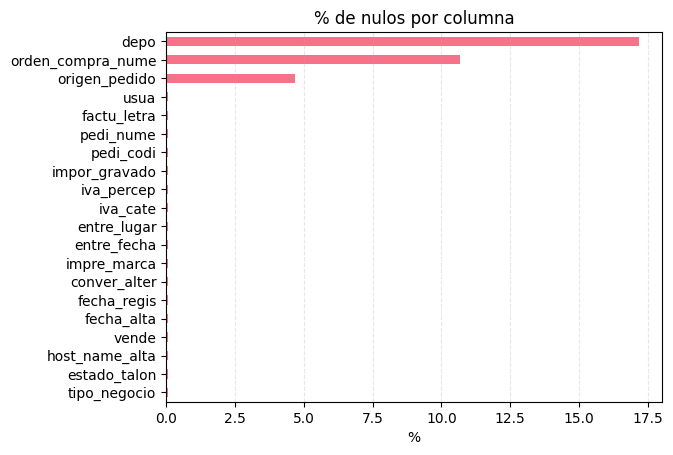

In [13]:
# Visualización del porcentaje de nulos por columna
null_df = (
    df.isna().sum()
      .to_frame("nulos")
      .assign(porc=lambda x: 100 * x["nulos"] / len(df))
      .query("nulos > 0")
      .sort_values("porc", ascending=False)
)

null_df["porc"].plot.barh()
plt.gca().invert_yaxis()
plt.title("% de nulos por columna")
plt.xlabel("%")
plt.grid(axis="x", alpha=0.3, linestyle="--")
plt.show()


In [14]:
# Porcentaje de nulos por fila
row_nulls = df.isna().mean(axis=1)
print("Filas con >50 % de nulos:", (row_nulls > 0.5).sum())


Filas con >50 % de nulos: 0


<Axes: >

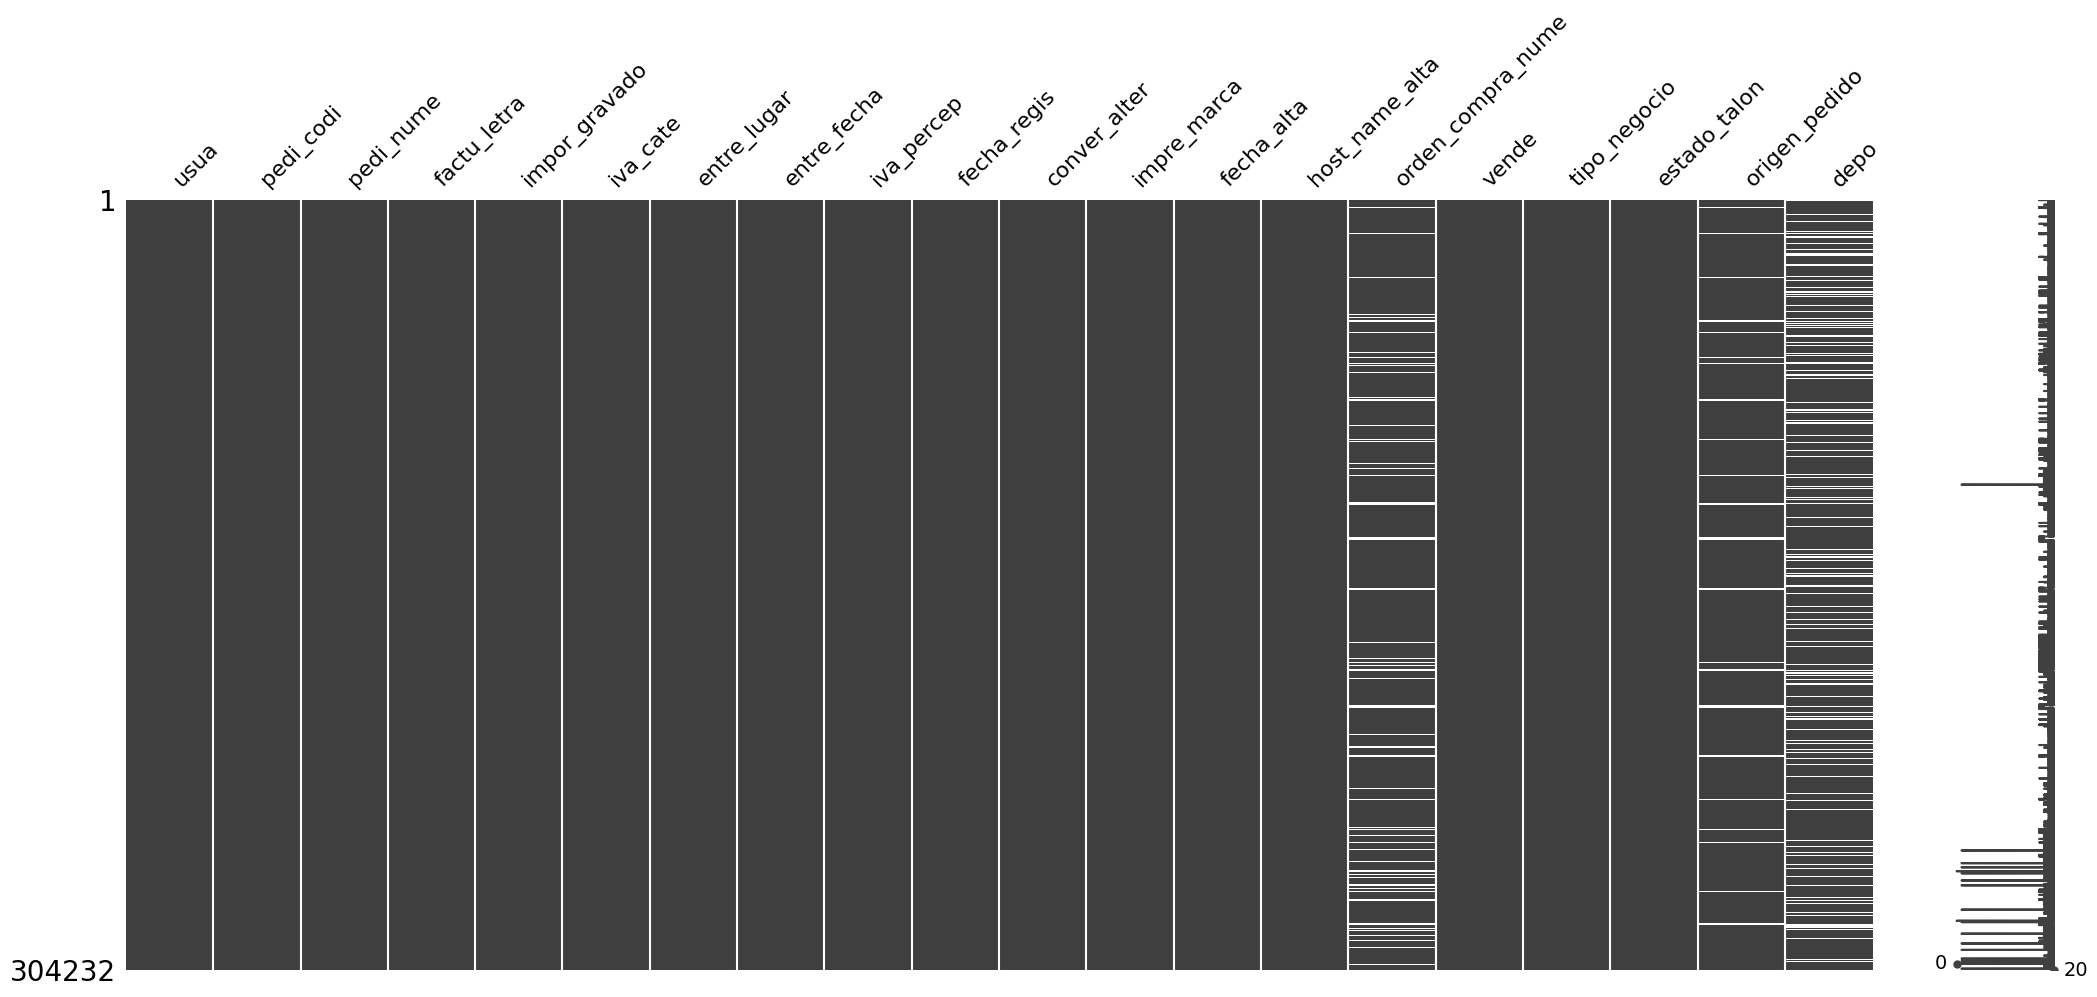

In [15]:
cols_with_na = df.columns[df.isna().any()]

import missingno as msno
msno.matrix(df[cols_with_na])



In [16]:
# Profundicemos en la correlacion entre los Datos Faltantes de las variables.

datos_faltantes = df[['depo', 'orden_compra_nume', 'origen_pedido']].isnull()
# datos_faltantes es una matriz tal que los valores faltantes se marcan True

datos_faltantes_corr = datos_faltantes.corr()
print(datos_faltantes_corr)



                       depo  orden_compra_nume  origen_pedido
depo               1.000000          -0.042772       0.031911
orden_compra_nume -0.042772           1.000000       0.637027
origen_pedido      0.031911           0.637027       1.000000


### 2.4 Actualización de valores por IPC

Deflactamos los precios por el IPC para traerlos a valor May_2025

In [17]:
# leemos el excel ipc-cba-mayo, la hoja IPC-Cba base 2014, fila 6 a 8
ipc_file_path = get_data_path('ipc-cba-mayo.xlsx')

ipc_df = pd.read_excel(ipc_file_path,sheet_name='Variaciones Mensuales',skiprows=4,nrows=3)

# Nos quedamos con los títulos y la fila donde código es == 100000 (alimentos y bebidas)
ipc_df = ipc_df[ipc_df['Código'] == 100000].reset_index(drop=True)

# pivoteo el data frame
ipc_df = ipc_df.melt(id_vars=['Código', 'Descripción'],var_name='Fecha',value_name='inflacion_mensual')

# pasamos a datetime la columna Fecha
ipc_df['Fecha'] = pd.to_datetime(ipc_df['Fecha'],format='%d/%m/%Y', errors='coerce')

# eliminamos primera fila que no tiene datos (la que venía como “NIVEL”)
ipc_df = ipc_df.dropna(subset=['Fecha', 'inflacion_mensual'])

ipc_df = ipc_df.sort_values('Fecha').reset_index(drop=True)

# calculamos el factor mensual
ipc_df['factor_mensual'] = 1 + ipc_df['inflacion_mensual'].astype(float)

# acumulado del producto para generar el índice
ipc_df['indice_inf'] = ipc_df['factor_mensual'].cumprod()

# ipc_df["indice_inf"] = ipc_df["indice_inf"].shift(fill_value=1)    # clave!

# valor del índice en mayo-25 
base_val = ipc_df.loc[ipc_df['Fecha'] == pd.Timestamp('2025-05-01'),'indice_inf'].iloc[0]
ipc_df['deflactor_may25'] = base_val / ipc_df['indice_inf']

df_deflactores = ipc_df[['Fecha', 'deflactor_may25']].copy()

# filtros para fechas
_fecha_min = df['fecha'].min().replace(day=1)
_fecha_max = (df['fecha'].max() + pd.offsets.MonthEnd(0))

df_deflactores = ipc_df[['Fecha', 'deflactor_may25']].copy()
df_deflactores = df_deflactores[
    (df_deflactores['Fecha'] >= _fecha_min) &
    (df_deflactores['Fecha'] <= _fecha_max)
]
print(f"Rango de fechas: {_fecha_min} a {_fecha_max}")
print(df_deflactores['Fecha'].min())
print(df_deflactores['Fecha'].max())
display(df_deflactores.head(15))
display(df_deflactores.info())



Rango de fechas: 2022-01-01 00:00:00 a 2024-06-30 00:00:00
2022-01-01 00:00:00
2024-06-01 00:00:00


,Fecha,deflactor_may25
96,2022-01-01,14.963490
97,2022-02-01,14.136730
98,2022-03-01,13.137187
99,2022-04-01,12.346502
100,2022-05-01,11.797100
101,2022-06-01,11.334240
102,2022-07-01,10.626755
103,2022-08-01,9.986586
104,2022-09-01,9.466043
105,2022-10-01,8.929135


<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 96 to 125
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Fecha            30 non-null     datetime64[ns]
 1   deflactor_may25  30 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 720.0 bytes


None

In [18]:
# preparamos las fechas
df_defl= df.copy()


df_defl['fecha']   = pd.to_datetime(df_defl['fecha'])
df_defl['periodo'] = df_defl['fecha'].dt.to_period('M')

df_deflactores = (df_deflactores.dropna(subset=['Fecha']).assign(periodo=lambda d: d['Fecha'].dt.to_period('M')).drop_duplicates(subset='periodo')[['periodo', 'deflactor_may25']])

# verificamos la cobertura
periodos_df   = set(df_defl['periodo'].unique())
periodos_defl = set(df_deflactores['periodo'].unique())
faltantes     = sorted(periodos_df - periodos_defl)
# print(periodos_df)
# print(periodos_defl)
# print(faltantes)

#mergeamos en base al periodo generado (en un futuro hacer con xarray todo el proceso de deflactar)
df_defl = (df_defl.merge(df_deflactores, on='periodo', how='left', indicator='_merge_defl')
)
# verificamos que no haya filas sin deflactor
assert (df_defl['_merge_defl'] != 'both').sum() == 0, "Hay filas sin deflactor (¿duplicados en periodos?)"
df_defl = df_defl.drop(columns=['_merge_defl'])                     # limpieza

# seleccionamos las columnas monetarias a deflactar (agregar de ser necesario)
cols_deflactar = [
    'total', 'iva1', 'impor_gravado', 'iva_percep', 'precio_uni',
    'boni_impor', 'iva1_impor', 'iva_percep_impor', 'impor_grava',
    'precio_uni_neto', 'precio_total'
]

# deflactar “in-place”
df_defl.loc[:, cols_deflactar] = (
    df_defl[cols_deflactar].div(df_defl['deflactor_may25'], axis=0)
)


print(df)

       factu_codi  factu_nume  sucur      fecha  cliente     total     iva1  \
0            fca9       16092      9 2022-01-17     4627   2611.29   453.20   
1            fca9       16092      9 2022-01-17     4627   2611.29   453.20   
2            fca9       16092      9 2022-01-17     4627   2611.29   453.20   
3            fca9       16092      9 2022-01-17     4627   2611.29   453.20   
4            fca9       16092      9 2022-01-17     4627   2611.29   453.20   
...           ...         ...    ...        ...      ...       ...      ...   
310212        feb        9376     12 2024-06-29     9155  37800.12  6560.35   
310213        feb        9376     12 2024-06-29     9155  37800.12  6560.35   
310214        feb        9376     12 2024-06-29     9155  37800.12  6560.35   
310215        feb        9376     12 2024-06-29     9155  37800.12  6560.35   
310216        feb        9396     12 2024-06-29     6971   5965.80  1035.39   

        lista_precios condi_venta  usua pedi_codi  

In [19]:
# Validamos no haber perdido datos
# Porcentaje de valores nulos por columna
nulos_porcentaje = (df_defl.isnull().sum() / len(df_defl)) * 100

# Mostrar % solo de columnas con valores nulos
print("Porcentaje de valores nulos por columna:")

#ordenamos de mayor a menor
nulos_porcentaje = nulos_porcentaje.sort_values(ascending=False)
print(nulos_porcentaje[nulos_porcentaje > 0])

Porcentaje de valores nulos por columna:
depo                 17.162889
orden_compra_nume    10.668832
origen_pedido         4.681953
iva_percep            0.049633
fecha_regis           0.049633
factu_letra           0.049633
entre_lugar           0.049633
iva_cate              0.049633
impor_gravado         0.049633
pedi_nume             0.049633
estado_talon          0.049633
impre_marca           0.049633
fecha_alta            0.049633
vende                 0.049633
host_name_alta        0.049633
conver_alter          0.049633
entre_fecha           0.049633
pedi_codi             0.049633
usua                  0.049633
tipo_negocio          0.049633
dtype: float64


### 2.5 Análisis de datos atípicos (outliers)

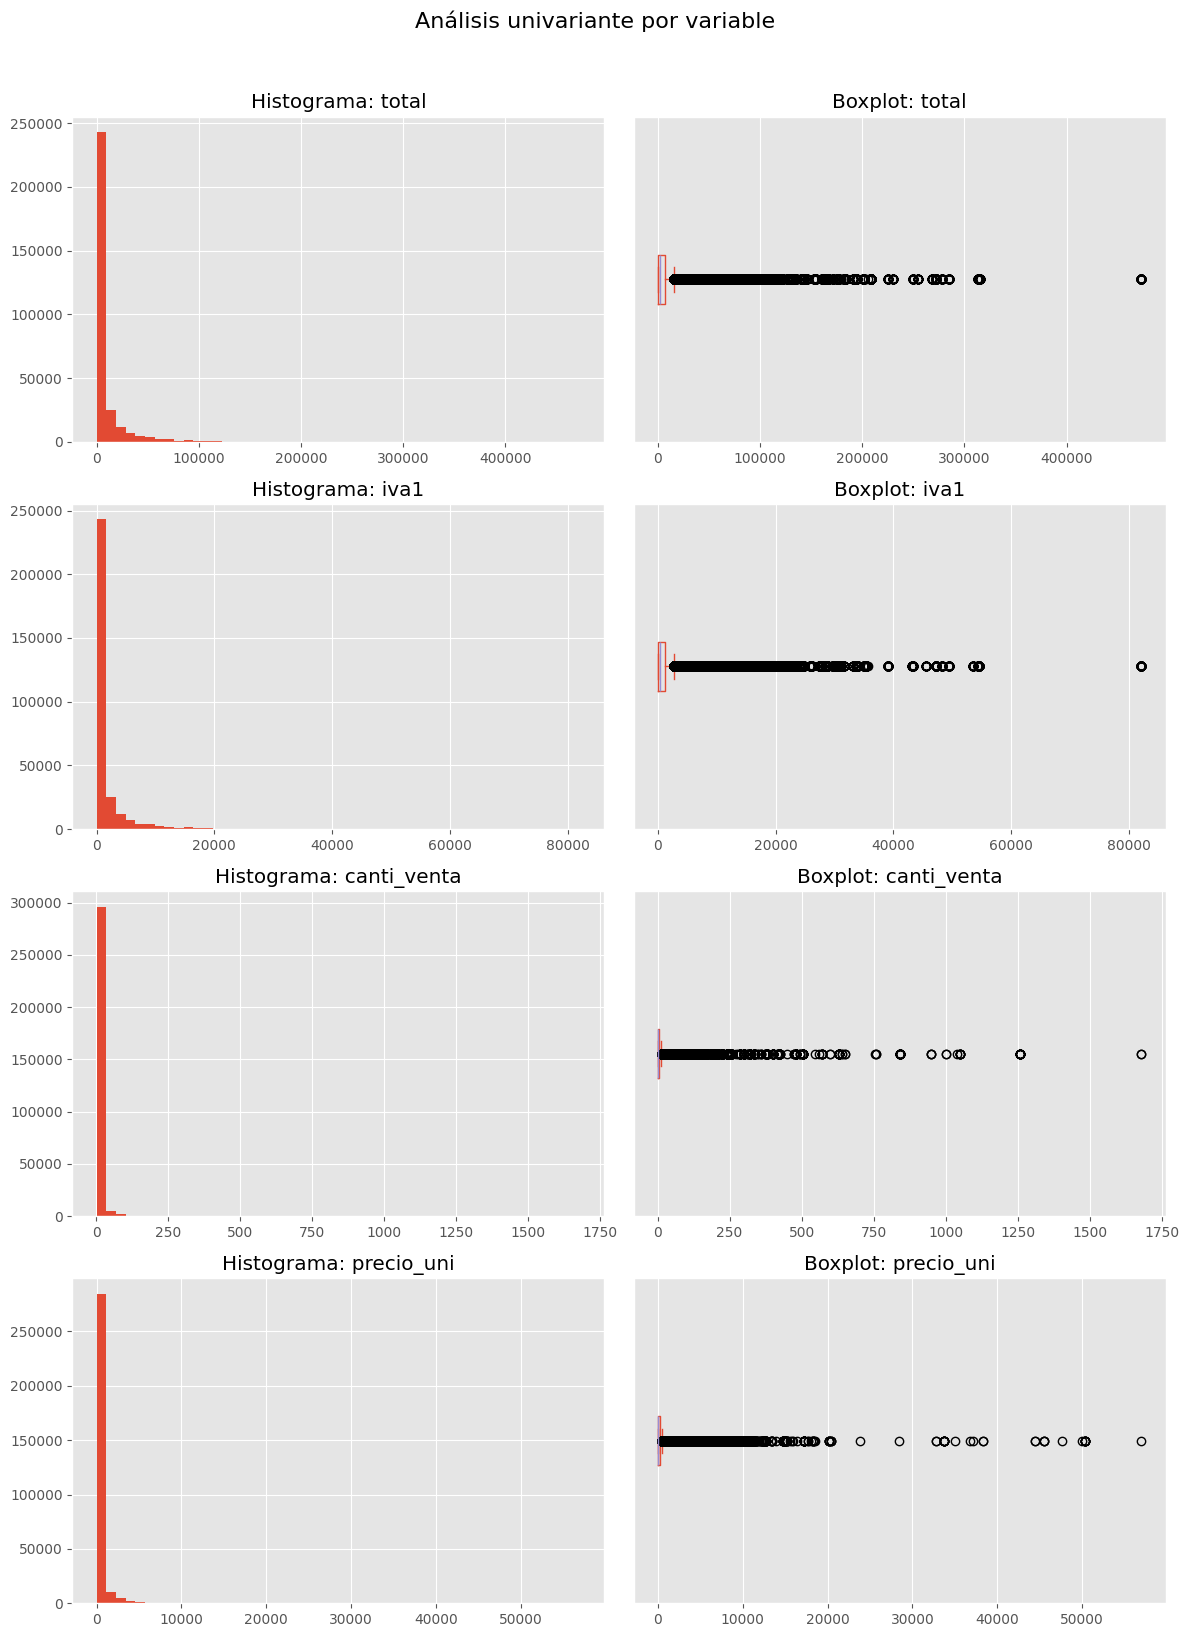

In [20]:
df_raw= df_defl.copy()

# Variables numéricas mas relevantes para el estudio (agregar las que se consideren necesarias)
_rel_columns = ["total", "iva1", "canti_venta", "precio_uni"]

plt.style.use('ggplot')

n = len(_rel_columns)
fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n), sharex=False)

for i, col in enumerate(_rel_columns):
    data = df_raw[col].dropna()

    # Histograma en la columna 0
    ax_h = axes[i, 0]
    data.plot.hist(ax=ax_h, bins=50, grid=True)
    ax_h.set_title(f"Histograma: {col}")
    ax_h.set_ylabel("")        # opcional: quita la etiqueta del eje Y para limpieza
    ax_h.ticklabel_format(axis='x', style='plain')  # evita notación científica

    # Boxplot en la columna 1
    ax_b = axes[i, 1]
    data.plot.box(ax=ax_b, vert=False, grid=True)
    ax_b.set_title(f"Boxplot: {col}")
    ax_b.set_yticks([])        # opcional: quita ticks del eje Y

plt.suptitle("Análisis univariante por variable", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


In [21]:
#Función para eliminar outliers por percentiles
def drop_percentile_outliers(df, cols, lower_q=0.01, upper_q=0.99):
    df0 = df.copy()
    bounds = {col: df0[col].quantile([lower_q, upper_q]).values
              for col in cols}
    mask = pd.Series(True, index=df0.index)
    for col, (lo, hi) in zip(bounds.keys(), bounds.values()):
        mask &= df0[col].between(lo, hi)
    return df0.loc[mask]

# Filtra registros imposibles (cantidad o precio <= 0)
df_clean = df_raw.copy()
mask_bad = (df_clean["canti_venta"] <= 0) | (df_clean["precio_uni"] <= 0)
df_clean = df_clean.loc[~mask_bad]
n_orig = len(df_clean)
df_clean = drop_percentile_outliers(df_clean, _rel_columns)
n_new  = len(df_clean)

print(f"Eliminadas {n_orig - n_new} filas ({(n_orig-n_new)/n_orig:.1%})")


Eliminadas 13190 filas (4.3%)


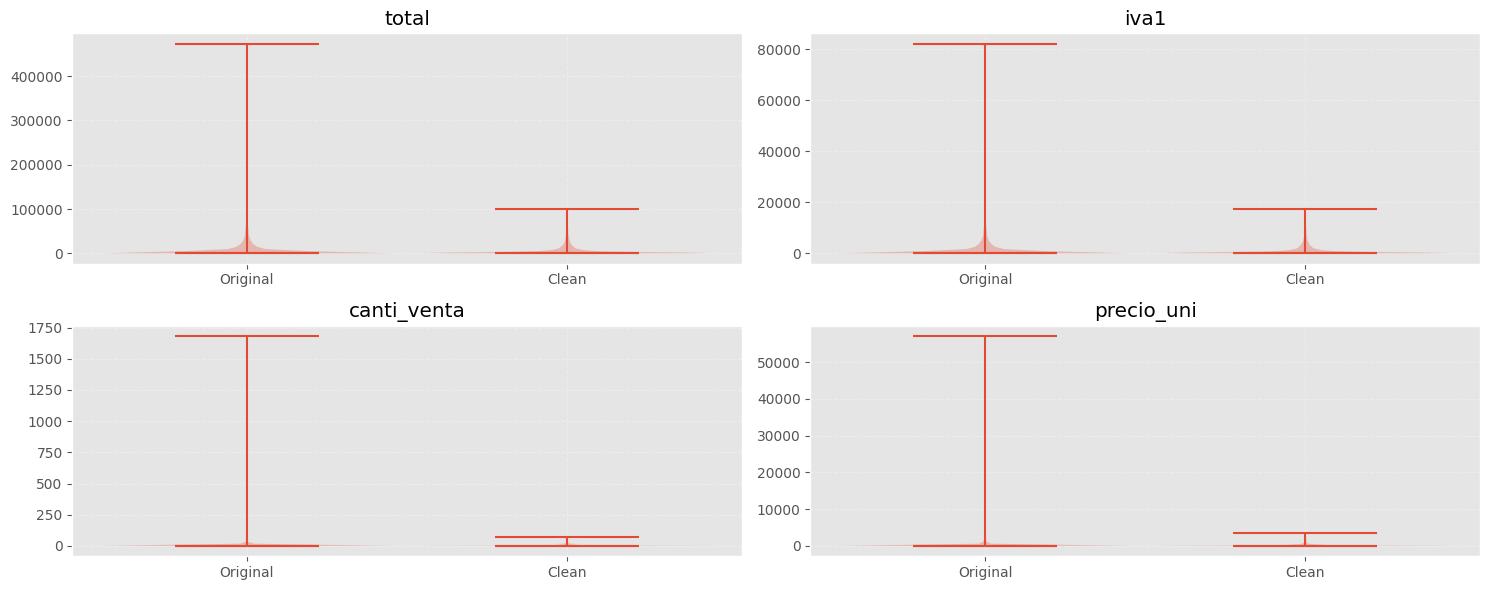

In [22]:
selected_cols = _rel_columns               # de querer agregar más variables, modificar la lista que se usa acá
n            = len(selected_cols)
cols         = 2                           # columnas de grid
rows         = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, selected_cols):
    data_orig  = df_raw[col].dropna()
    data_clean = df_clean[col].dropna()

    ax.violinplot(
        [data_orig, data_clean],
        positions=[1, 2],
        widths=0.9,
        showmeans=False,
        showmedians=True
    )
    ax.set_title(col)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Original', 'Clean'])
    ax.grid(True, linestyle='--', alpha=0.3)

# elimina ejes sobrantes si el grid es mayor que el nº de variables!
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

## 3. Análisis Descriptivo

### 3.1 Estadísticas Descriptivas

In [23]:
# Estadísticas descriptivas

df_an_desc= df_clean.copy()

# var numéricas que estan como object 
suspect_numeric = ["boni_porcen_precio", "boni_impor_precio",
                   "conver", "conver_alter"]

for col in suspect_numeric:
    df_an_desc[col] = pd.to_numeric(df_an_desc[col], errors="coerce")

#primero transformamos en obj las columnas las cuales no agregan valor a nuestro analisis descriptivo
cat_cols = [
    "factu_nume", "sucur", "cliente", "lista_precios", "usua",
    "pedi_nume", "entre_lugar", "impre_marca",
    "orden_compra_nume", "vende", "tipo_negocio", "linea_nume",
    "depo", "estado_talon", "origen_pedido", "factu_letra",
    "iva_cate"
]
df_an_desc[cat_cols] = df_an_desc[cat_cols].astype("category")


num_stats = df_an_desc.select_dtypes(include=["number"]).describe().T
display(num_stats)


from pandas.api.types import is_datetime64_any_dtype
date_cols = [c for c in df_an_desc.columns if is_datetime64_any_dtype(df_an_desc[c])]
date_summary = pd.DataFrame({
    "min": df_an_desc[date_cols].min(),
    "max": df_an_desc[date_cols].max(),
    "range_days": (df_an_desc[date_cols].max() - df_an_desc[date_cols].min()).dt.days
})
display(date_summary)

# Análisis de variables categóricas
for col in df_an_desc.select_dtypes(include=['object']).columns:
    print(f"\nDistribución de {col}:")
    print(df_an_desc[col].value_counts())



,count,mean,std,min,25%,50%,75%,max
total,291042.0,7.117257e+03,1.392437e+04,50.566665,562.148896,1728.349875,6137.523498,1.003211e+05
iva1,291042.0,1.230286e+03,2.401806e+03,8.775886,96.911394,299.065911,1062.743409,1.727908e+04
impor_gravado,290902.0,5.852658e-03,1.143158e-02,0.000042,0.000461,0.001424,0.005056,8.228132e-02
iva_percep,290902.0,2.838461e+01,2.277827e+02,0.000000,0.000000,0.000000,0.000000,9.036402e+03
conver_alter,290902.0,7.690653e-01,3.130039e-01,0.344828,0.344828,1.000000,1.000000,1.000000e+00
canti,291042.0,2.110731e+01,7.128611e+01,1.000000,3.000000,6.000000,12.000000,4.625000e+03
precio_uni,291042.0,2.244768e+02,4.959831e+02,1.075657,15.958303,49.296126,187.839840,3.603058e+03
boni_porcen,291042.0,2.203531e+05,2.503454e+06,0.000000,0.000000,0.000000,0.000000,1.000000e+08
boni_impor,291042.0,2.669037e+06,4.690648e+07,0.000000,0.000000,0.000000,0.000000,6.598578e+09
iva1_impor,291042.0,1.136723e+02,2.451297e+02,0.000000,11.303162,28.139097,93.563172,1.369516e+04


,min,max,range_days
fecha,2022-01-03 00:00:00.000,2024-06-29 00:00:00.000,908
entre_fecha,2022-01-03 00:00:00.000,2024-07-02 00:00:00.000,911
fecha_regis,2022-01-03 00:00:00.000,2024-06-29 00:00:00.000,908
fecha_alta,2022-01-03 11:52:27.027,2024-06-29 13:07:20.990,908



Distribución de factu_codi:
factu_codi
fea1     212094
feb1      31368
fea       26022
fca9      10577
feb        5111
fea4       4279
feb4        728
fca09       595
fcb9        268
Name: count, dtype: int64

Distribución de condi_venta:
condi_venta
00       228306
07        30492
mp        15592
14         8728
21         5011
47         1371
28         1010
srhg        244
srch        142
micro        87
888          59
Name: count, dtype: int64

Distribución de pedi_codi:
pedi_codi
pedi     278018
pedim     12882
pedie         2
Name: count, dtype: int64

Distribución de host_name_alta:
host_name_alta
srvdc902    121805
nbdc-029    115692
server01     28805
nbdc-030     18342
server        6003
server03       255
Name: count, dtype: int64

Distribución de nombre:
nombre
Guillermina Franco Fernandez    4650
Mateo Joaquin Mateo Aguirre     4370
Jazmin Lola Ferreyra            3933
Bautista Benjamin Godoy         3418
Santiago Martinez               3408
                             

In [24]:
display(df_an_desc['factu_letra'].value_counts(normalize=True) * 100)

factu_letra
a    87.129343
b    12.870657
Name: proportion, dtype: float64

### 3.2 Resumen Ejecutivo

In [25]:
# Resumen ejecutivo del dataset
print("==========================================")
print("RESUMEN EJECUTIVO DEL DATASET DE VENTAS")
print("==========================================")

unique_totals = df_an_desc.drop_duplicates(subset='factu_nume')['total']

total_transacciones = len(df_an_desc["factu_nume"].unique())
total_facturacion = unique_totals.sum()
ticket_promedio = unique_totals.mean()
ticket_mediano = unique_totals.median()

fecha_inicio = df_an_desc['fecha'].min()
fecha_fin = df_an_desc['fecha'].max()
dias_operacion = (fecha_fin - fecha_inicio).days

clientes_unicos = df_an_desc['cliente'].nunique()
productos_unicos = df_an_desc['descrip'].nunique()
sucursales = df_an_desc['sucur'].nunique()

print("\nMÉTRICAS GENERALES:")
print(f"   - Total de transacciones: {total_transacciones:,}")
print(f"   - Facturación total: ${total_facturacion:,.0f}")
print(f"   - Ticket promedio: ${ticket_promedio:,.0f}")
print(f"   - Ticket mediano: ${ticket_mediano:,.0f}")
print(f"   - Período: {fecha_inicio.strftime('%d/%m/%Y')} - {fecha_fin.strftime('%d/%m/%Y')} ({dias_operacion} días)")

print("\nESTRUCTURA DEL NEGOCIO:")
print(f"   - Sucursales: {sucursales}")
print(f"   - Clientes únicos: {clientes_unicos:,}")
print(f"   - Productos únicos: {productos_unicos:,}")
print(f"   - Promedio transacciones/día: {total_transacciones/dias_operacion:.1f}")
factu_letra_pct = df_an_desc['factu_letra'].value_counts(normalize=True) * 100

print(f"   - Ventas Mayoristas (A): {factu_letra_pct.get('a', 0):.2f}%")
print(f"   - Ventas Minoristas (B): {factu_letra_pct.get('b', 0):.2f}%")


RESUMEN EJECUTIVO DEL DATASET DE VENTAS

MÉTRICAS GENERALES:
   - Total de transacciones: 38,788
   - Facturación total: $162,002,674
   - Ticket promedio: $4,177
   - Ticket mediano: $810
   - Período: 03/01/2022 - 29/06/2024 (908 días)

ESTRUCTURA DEL NEGOCIO:
   - Sucursales: 3
   - Clientes únicos: 567
   - Productos únicos: 3,632
   - Promedio transacciones/día: 42.7
   - Ventas Mayoristas (A): 87.13%
   - Ventas Minoristas (B): 12.87%


## 4. Visualizaciones Clave

### 4.1 Análisis Temporal

In [26]:
# Preparación de datos temporales
df_viz_desc= df_clean.copy()
df_viz_desc['año'] = df_viz_desc['fecha'].dt.year
df_viz_desc['mes'] = df_viz_desc['fecha'].dt.month
df_viz_desc['dia'] = df_viz_desc['fecha'].dt.day
df_viz_desc['dia_semana'] = df_viz_desc['fecha'].dt.day_name()

# Asegurarse de que 'dia_semana' exista en df para las visualizaciones
if 'dia_semana' not in df.columns:
    df['dia_semana'] = df['fecha'].dt.day_name()


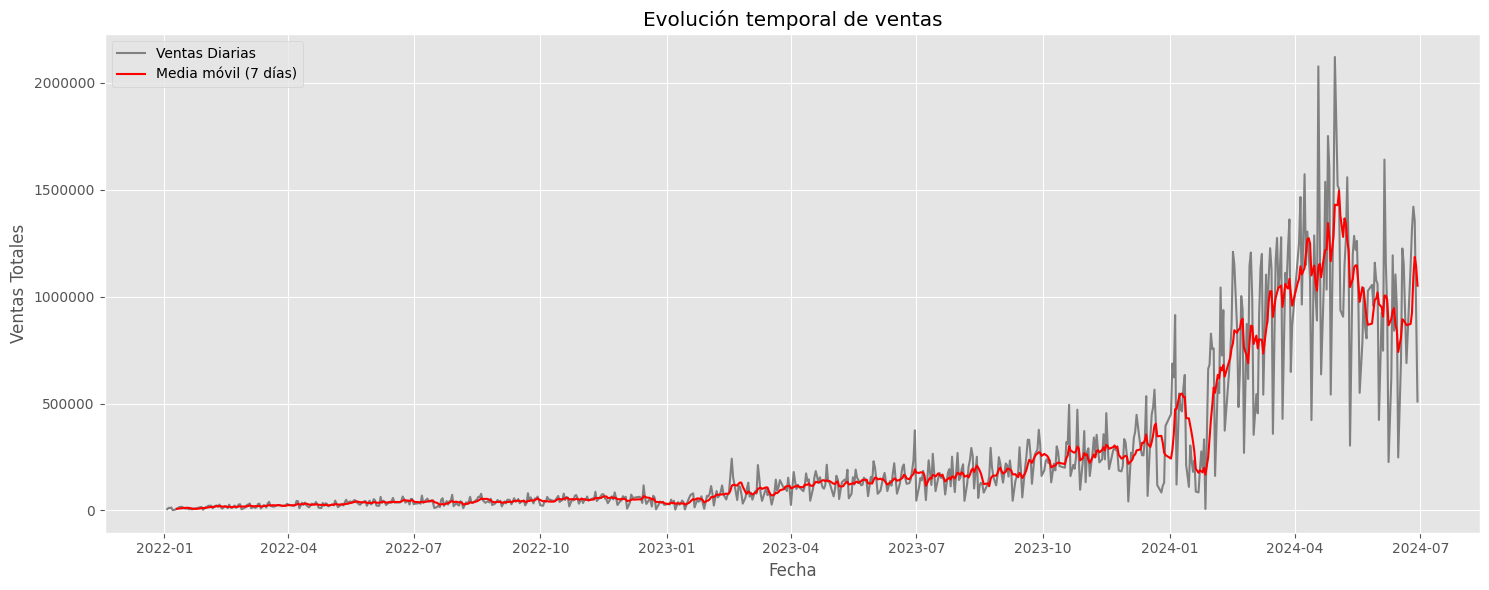

In [27]:
# Calculamos la media móvil de 7 días y comparámos con el total de ventas diarias


ventas_diarias = df_viz_desc.groupby('fecha')['precio_total'].sum().reset_index() #cambiado "total" (total de la factura, repetido en varias filas) x "precio_total" (el total de cada producto comprado)
ventas_diarias['media_movil'] = ventas_diarias['precio_total'].rolling(window=7).mean()

plt.figure(figsize=(15, 6))
sns.lineplot(data=ventas_diarias, x='fecha', y='precio_total', label='Ventas Diarias', color='grey')
sns.lineplot(data=ventas_diarias, x='fecha', y='media_movil', label='Media móvil (7 días)', color='red')

plt.title('Evolución temporal de ventas')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.ticklabel_format(style='plain', axis='y')  # evita notación científica
plt.legend()
plt.tight_layout()
plt.show()


Del gráfico de evolución temporal podemos extraer las siguientes conclusiones generales:

#### 1. Tendencia General
- **Tendencia creciente**: Se observa un patrón de crecimiento sostenido a lo largo del período analizado (2022–2024).
- **Aceleración en 2024**: Las ventas muestran una marcada aceleración desde principios de 2024.

#### 2. Estacionalidad y Patrones Cíclicos
- **Ciclos mensuales**: Se observan picos regulares que podrían sugerir patrones de fin de mes o quincenales.
- **Ciclos anuales**: Notamos mesetas de estancamiento cerca del mes de Enero a partir del 2023
- **Volatilidad controlada**: La media móvil de 7 días suaviza las fluctuaciones diarias y revela la tendencia subyacente más claramente.
- **Ausencia de estacionalidad anual marcada**: No se observan movimientos pronunciados que evidencien relación con temporadas específicas.

#### 3. Volatilidad y Variabilidad
- **Alta volatilidad diaria**: Las ventas diarias (línea gris) muestran considerable variabilidad día a día.
- **Tendencia estable suavizada**: La media móvil (línea roja) confirma la consistencia del crecimiento sin grandes disrupciones.
- **Incremento en la variabilidad**: A medida que aumenta el volumen de ventas, también aumenta la amplitud de las fluctuaciones.



### 4.2 Patrones Semanales y Mensuales

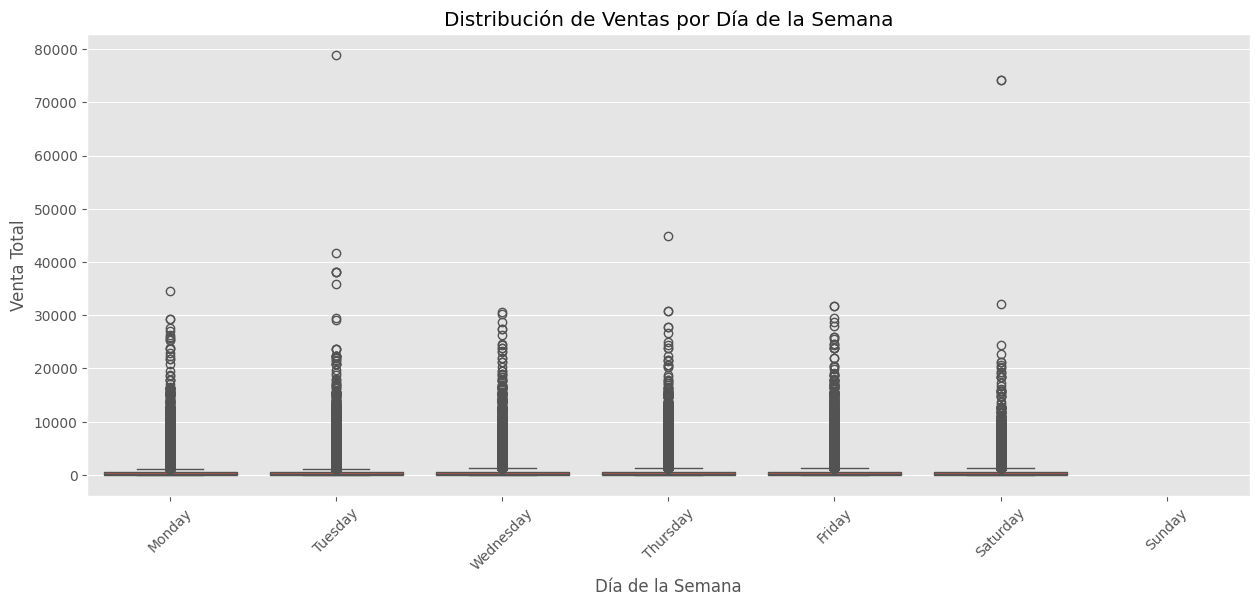

In [28]:
# 4.2 Patrones Semanales
plt.figure(figsize=(15, 6))
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(data=df_viz_desc, x='dia_semana', y='precio_total', order=dias_orden)
plt.title('Distribución de Ventas por Día de la Semana')
plt.xticks(rotation=45)
plt.xlabel('Día de la Semana')
plt.ylabel('Venta Total')
plt.show()



In [29]:
df_viz_desc.columns

Index(['factu_codi', 'factu_nume', 'sucur', 'fecha', 'cliente', 'total',
       'iva1', 'lista_precios', 'condi_venta', 'usua', 'pedi_codi',
       'pedi_nume', 'factu_letra', 'impor_gravado', 'iva_cate', 'entre_lugar',
       'entre_fecha', 'iva_percep', 'fecha_regis', 'conver_alter',
       'impre_marca', 'fecha_alta', 'host_name_alta', 'nombre', 'cuit',
       'orden_compra_nume', 'vende', 'tipo_negocio', 'estado_talon',
       'origen_pedido', 'linea_nume', 'depo', 'produc', 'canti', 'precio_uni',
       'boni_porcen', 'boni_impor', 'iva1_impor', 'descrip',
       'iva_percep_porcen', 'iva_percep_impor', 'impor_grava', 'uni_medi',
       'conver', 'canti_venta', 'boni_porcen_precio', 'boni_impor_precio',
       'precio_uni_neto', 'precio_total', 'periodo', 'deflactor_may25', 'año',
       'mes', 'dia', 'dia_semana'],
      dtype='object')

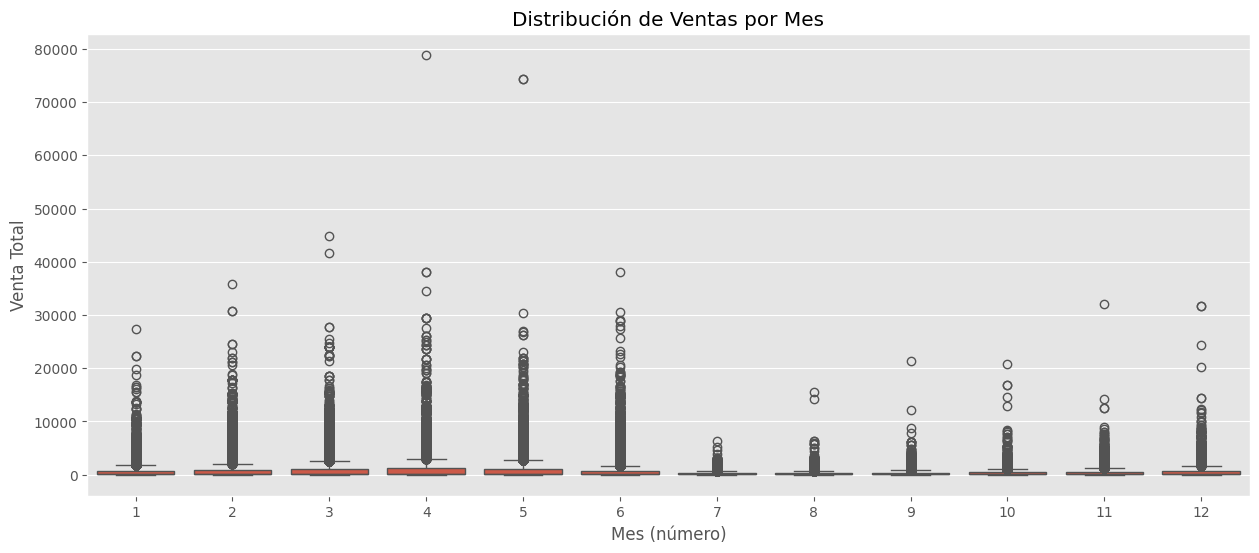

In [30]:

plt.figure(figsize=(15, 6))
sns.boxplot(data=df_viz_desc, x='mes', y='precio_total')
plt.title('Distribución de Ventas por Mes')
plt.xlabel('Mes (número)')
plt.ylabel('Venta Total')
plt.show()


### 4.3 Análisis por Punto de Venta y Producto

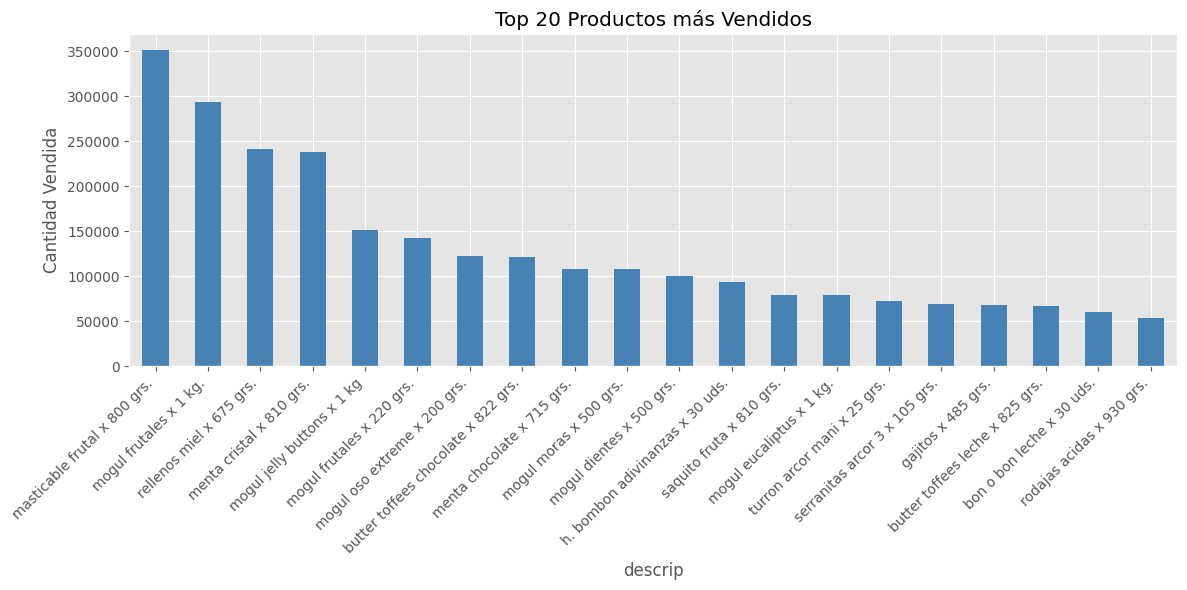

In [31]:
# Top productos por cantidad vendida

top_productos = df_viz_desc.groupby('descrip')['canti'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
top_productos.plot(kind='bar', color='steelblue')
plt.title('Top 20 Productos más Vendidos')
plt.ylabel('Cantidad Vendida')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


C:\Users\marti\AppData\Local\Temp\ipykernel_16564\4262071710.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_prod.index, ha='right')


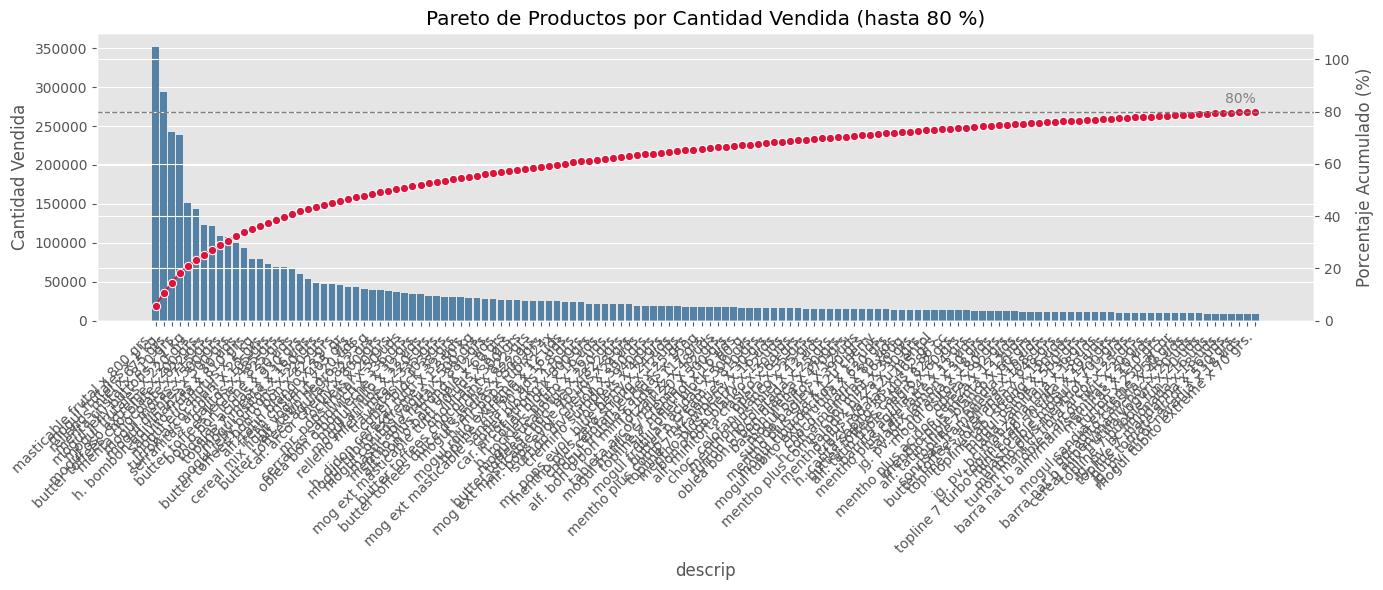

In [32]:
# Pareto de Productos  por cantidad de ventas

ventas = (
    df_viz_desc.groupby('descrip')['canti']
      .sum()
      .sort_values(ascending=False)
)

pct_cum = ventas.cumsum() / ventas.sum() * 100

mask = pct_cum <= 80
if not mask.iloc[-1]:                           # garantizar incluir el que supera 80
    first_over = mask[mask == False].index[0]
    mask.loc[first_over] = True

top_prod  = ventas[mask]
pct_cum80 = pct_cum[top_prod.index]


fig, ax1 = plt.subplots(figsize=(14, 6))


sns.barplot(
    x=top_prod.index,
    y=top_prod.values,
    ax=ax1,
    color='steelblue'
)
ax1.set_ylabel('Cantidad Vendida')
ax1.set_title('Pareto de Productos por Cantidad Vendida (hasta 80 %)')
ax1.tick_params(axis='x', rotation=45)
ax1.set_xticklabels(top_prod.index, ha='right')


ax2 = ax1.twinx()
sns.lineplot(
    x=top_prod.index,
    y=pct_cum80.values,
    ax=ax2,
    color='crimson',
    marker='o'
)
ax2.set_ylabel('Porcentaje Acumulado (%)')
ax2.set_ylim(0, 110)
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.text(len(top_prod) - 1, 82, '80%', color='gray',
         va='bottom', ha='right')

plt.tight_layout()
plt.show()



In [33]:

pct_cum = ventas.cumsum() / ventas.sum()


mask = pct_cum <= 0.80
if not mask.iloc[-1]:
    mask.loc[pct_cum[mask == False].index[0]] = True


productos_80 = pd.DataFrame({
    'unidades': ventas[mask],
    'porcentaje': (pct_cum[mask] * 100).round(2)
})

print(f"Productos que explican el 80 % de unidades (N={len(productos_80)})")
display(productos_80)


Productos que explican el 80 % de unidades (N=138)


,unidades,porcentaje
descrip,,
masticable frutal x 800 grs.,351504.0,5.72
mogul frutales x 1 kg.,293578.0,10.50
rellenos miel x 675 grs.,242055.0,14.44
menta cristal x 810 grs.,238273.0,18.32
mogul jelly buttons x 1 kg,151193.0,20.78
...,...,...
jg. pv. bc limonada x 18 uds.,8946.0,79.50
topline 7 mandarina x 16 uds.,8800.0,79.64
pure tomate arcor x 530 grs.,8777.0,79.79


In [34]:
_cant_productos= df_viz_desc['descrip'].nunique()
print(f"Cantidad de productos únicos: {_cant_productos}")
print((len(productos_80)/_cant_productos)*100)

Cantidad de productos únicos: 3632
3.7995594713656384


Podemos visualizar en este pareto que 131 productos (3.44% de la totalidad de nuestros productos), representa el 80% de nuestras ventas

Análisis por Punto de Venta

In [35]:
# porcentaje de UNIDADES vendidas por punto de venta 
units_pdv = (
    df_viz_desc.groupby('sucur')['canti']       # ver si cambiar esta columna por canti
      .sum()
      .reset_index()
      .rename(columns={'canti': 'unidades'})
)

units_pdv['porcentaje'] = 100 * units_pdv['unidades'] / units_pdv['unidades'].sum()

fig = px.pie(
    units_pdv,
    values='porcentaje',
    names='sucur',
    title='Porcentaje de UNIDADES vendidas por Punto de Venta'
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(title_x=0.5, title_font_size=20)
fig.show()

#porcentaje de FACTURACIÓN por punto de venta
revenue_pdv = (
    df.groupby('sucur')['total']
      .sum()
      .reset_index()
      .rename(columns={'total': 'facturacion'})
)

revenue_pdv['porcentaje'] = 100 * revenue_pdv['facturacion'] / revenue_pdv['facturacion'].sum()

fig = px.pie(
    revenue_pdv,
    values='porcentaje',
    names='sucur',
    title='Porcentaje de FACTURACIÓN por Punto de Venta'
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(title_x=0.5, title_font_size=20)
fig.show()


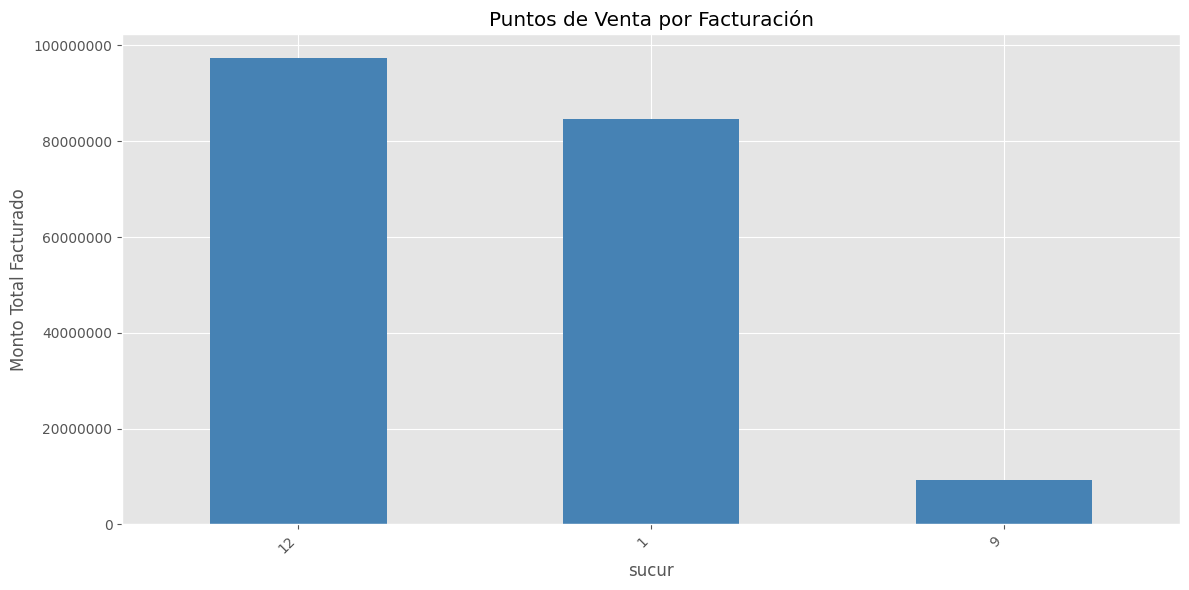

In [36]:
top_pdv = df_viz_desc.groupby('sucur')['precio_total'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
top_pdv.plot(kind='bar', color='steelblue')
plt.title('Puntos de Venta por Facturación')
plt.ylabel('Monto Total Facturado')
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')  # evita notación científica
plt.tight_layout()
plt.show()


C:\Users\marti\AppData\Local\Temp\ipykernel_16564\2535419365.py:42: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\marti\AppData\Local\Temp\ipykernel_16564\2535419365.py:42: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\marti\AppData\Local\Temp\ipykernel_16564\2535419365.py:42: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



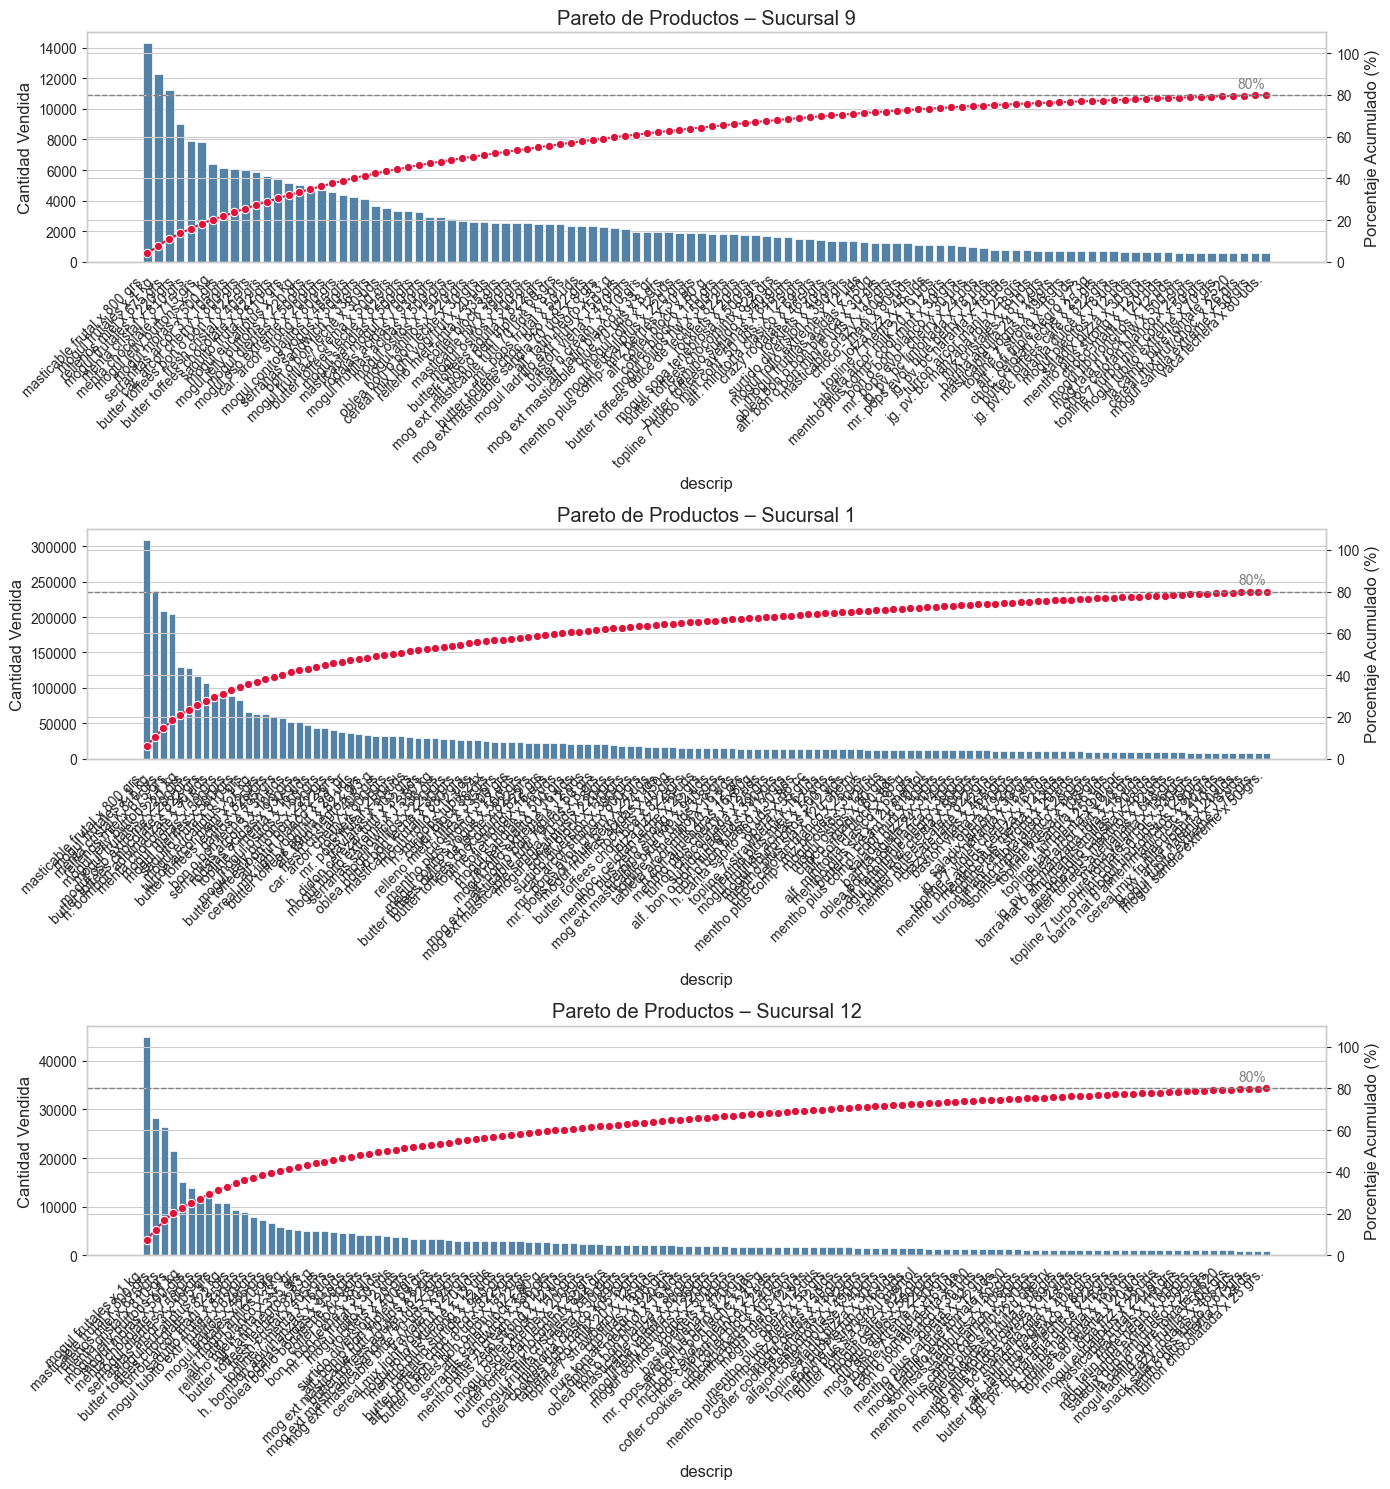

In [37]:
sns.set_style("whitegrid")

sucursales = df_viz_desc['sucur'].unique()     
fig, axes = plt.subplots(
    nrows=len(sucursales),
    ncols=1,
    figsize=(14, 5 * len(sucursales)),
    sharex=False
)

for ax, suc in zip(axes, sucursales):

    ventas = (
        df_viz_desc.loc[df_viz_desc['sucur'] == suc]
          .groupby('descrip')['canti']
          .sum()
          .sort_values(ascending=False)
    )


    pct_cum = ventas.cumsum() / ventas.sum() * 100


    mask = pct_cum <= 80
    if not mask.iloc[-1]:                 
        first_over = mask[mask == False].index[0]
        mask.loc[first_over] = True

    top_prod   = ventas[mask]
    pct_cum80  = pct_cum[top_prod.index]


    sns.barplot(
        x=top_prod.index,
        y=top_prod.values,
        ax=ax,
        color='steelblue'
    )
    ax.set_ylabel('Cantidad Vendida')
    ax.set_title(f'Pareto de Productos – Sucursal {suc}')
    ax.tick_params(axis='x', rotation=45)
    ax.set_xticklabels(top_prod.index, ha='right')

    ax2 = ax.twinx()
    sns.lineplot(
        x=top_prod.index,
        y=pct_cum80.values,
        ax=ax2,
        color='crimson',
        marker='o'
    )
    ax2.set_ylabel('Porcentaje Acumulado (%)')
    ax2.set_ylim(0, 110)
    ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
    ax2.text(len(top_prod) - 1, 82, '80%', color='gray',
             va='bottom', ha='right')

plt.tight_layout()
plt.show()


In [38]:

top80_dict = {}     

for suc in sucursales:

    ventas = (
        df_viz_desc.loc[df_viz_desc['sucur'] == suc]
          .groupby('descrip')['canti']
          .sum()
          .sort_values(ascending=False)
    )


    pct_cum = ventas.cumsum() / ventas.sum()


    mask = pct_cum <= 0.80
    if not mask.iloc[-1]:                              
        mask.loc[pct_cum[mask == False].index[0]] = True


    top80_dict[suc] = pd.DataFrame({
        'unidades': ventas[mask],
        'porcentaje': (pct_cum[mask] * 100).round(2)
    })


for suc, tabla in top80_dict.items():
    print(f"\n Sucursal {suc} — productos que explican el 80 % (N={len(tabla)})")
    display(tabla)



 Sucursal 9 — productos que explican el 80 % (N=104)


,unidades,porcentaje
descrip,,
masticable frutal x 800 grs.,14278.0,4.19
mogul frutales x 1 kg.,12265.0,7.78
rellenos miel x 675 grs.,11205.0,11.07
mogul frutales x 220 grs.,9000.0,13.71
menta cristal x 810 grs.,7920.0,16.03
...,...,...
mogul tubito extreme x 70 grs.,576.0,79.36
la camp. pure tomate x 520,568.0,79.52
cereal mix frut/choc. x 26 grs.,560.0,79.69



 Sucursal 1 — productos que explican el 80 % (N=133)


,unidades,porcentaje
descrip,,
masticable frutal x 800 grs.,309034.0,5.94
mogul frutales x 1 kg.,236325.0,10.48
menta cristal x 810 grs.,208875.0,14.49
rellenos miel x 675 grs.,204420.0,18.42
mogul jelly buttons x 1 kg,129664.0,20.91
...,...,...
macucas x 110 grs.,8152.0,79.43
cereal mix frutilla yogurt x 20 uds.,8090.0,79.59
jg. pv. arcor naranja x 18 uds.,7902.0,79.74



 Sucursal 12 — productos que explican el 80 % (N=127)


,unidades,porcentaje
descrip,,
mogul frutales x 1 kg.,44988.0,7.54
masticable frutal x 800 grs.,28192.0,12.26
rellenos miel x 675 grs.,26430.0,16.68
menta cristal x 810 grs.,21478.0,20.28
mogul jelly buttons x 1 kg,15148.0,22.82
...,...,...
mogul ladrillo extr frutilla x 500 grs,1000.0,79.36
crazy rodajas x 465 grs.,980.0,79.52
snack sala corss fuego x 67 grs.,978.0,79.69


In [39]:
#conclusión

for suc, tabla in top80_dict.items():
    cant_top          = len(tabla)                                  
    cant_prod_sucursal = df_viz_desc.loc[df_viz_desc['sucur'] == suc, 'descrip'].nunique()  # catálogo de esa suc.
    pct_cat_suc       = cant_top / cant_prod_sucursal * 100   
    
    print(f"Sucursal {suc}:")
    print(f"  • Productos que explican 80 % de unidades: {cant_top}")
    print(f"  • Porcentaje de SU catálogo: {pct_cat_suc:.2f}%\n")


Sucursal 9:
  • Productos que explican 80 % de unidades: 104
  • Porcentaje de SU catálogo: 6.65%

Sucursal 1:
  • Productos que explican 80 % de unidades: 133
  • Porcentaje de SU catálogo: 3.88%

Sucursal 12:
  • Productos que explican 80 % de unidades: 127
  • Porcentaje de SU catálogo: 10.16%



### 4.4 Relacion entre Frecuencia de Compra y Volumen de Ventas (por cliente)
Vamos a abordarlo desde la perspectiva de cada cliente y en 1 año

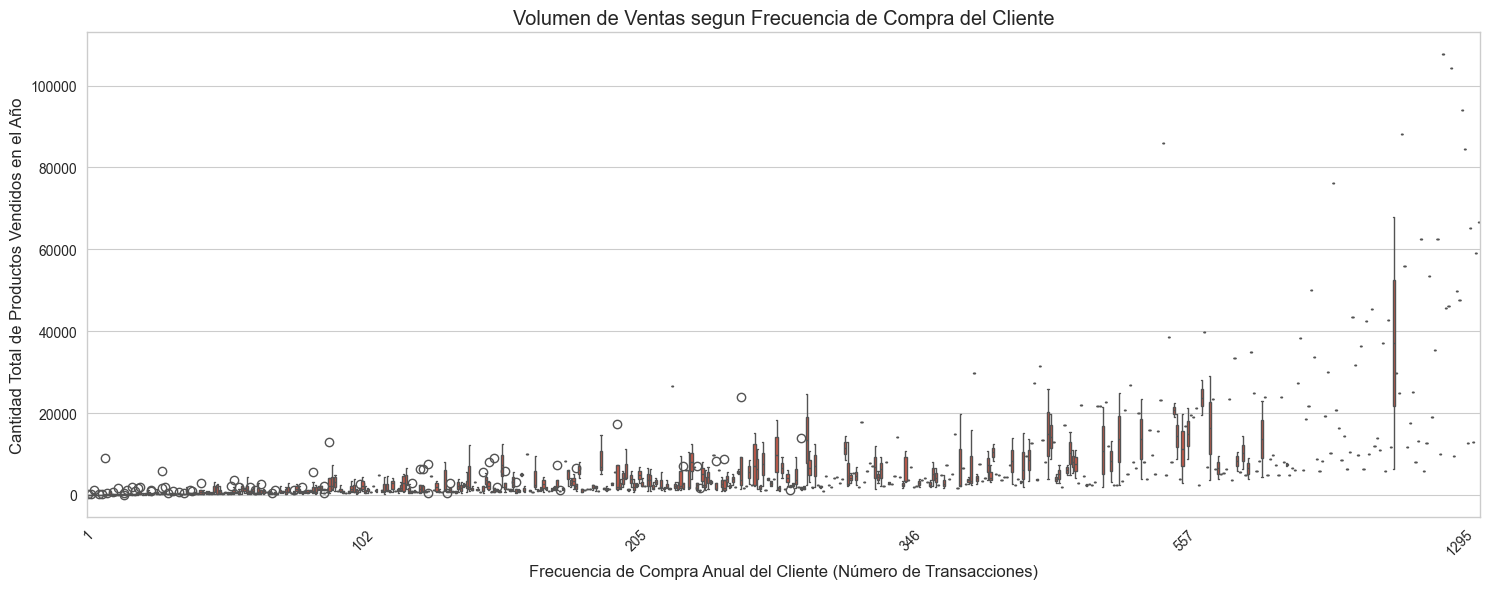

In [40]:

# Cuenta cuántas veces aparece cada combinación cliente-año en el DataFrame
df_viz_desc['frecuencias'] = df_viz_desc.groupby(['cliente', 'año'])['cliente'].transform('count')

# Calcular cantidad TOTAL de productos vendidos por cliente-año
df_viz_desc['cantidad_total_anual'] = df_viz_desc.groupby(['cliente', 'año'])['canti'].transform('sum')

# Crear un DataFrame único por cliente-año para evitar duplicados
df_cliente_anual = df_viz_desc.groupby(['cliente', 'año']).agg({
    'frecuencias': 'first',  # Frecuencia de compra (número de transacciones)
    'canti': 'sum',       # Cantidad total de productos en el año
    'precio_total': 'sum'  # Monto total anual (para comparar)
}).reset_index()

# Renombrar columnas para mayor claridad
df_cliente_anual.rename(columns={
    'canti': 'cantidad_total_anual',  # Corregido: era 'cantidad' ahora es 'canti'
    'precio_total': 'monto_total_anual'
}, inplace=True)

# Gráfico principal: Cantidad total anual de productos según frecuencia de compra
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_cliente_anual, x='frecuencias', y='cantidad_total_anual')
# Configurar los ticks del eje x: cada N valores
xticks = plt.gca().get_xticks()
xticks_step = 100  # Cambiá esto para más/menos densidad
plt.xticks(ticks=xticks[::xticks_step], rotation=45)
plt.title('Volumen de Ventas segun Frecuencia de Compra del Cliente')
plt.xlabel('Frecuencia de Compra Anual del Cliente (Número de Transacciones)')
plt.ylabel('Cantidad Total de Productos Vendidos en el Año')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5. Análisis de Granularidad Temporal

### 5.1 Análisis de ventas totales por índice temporal

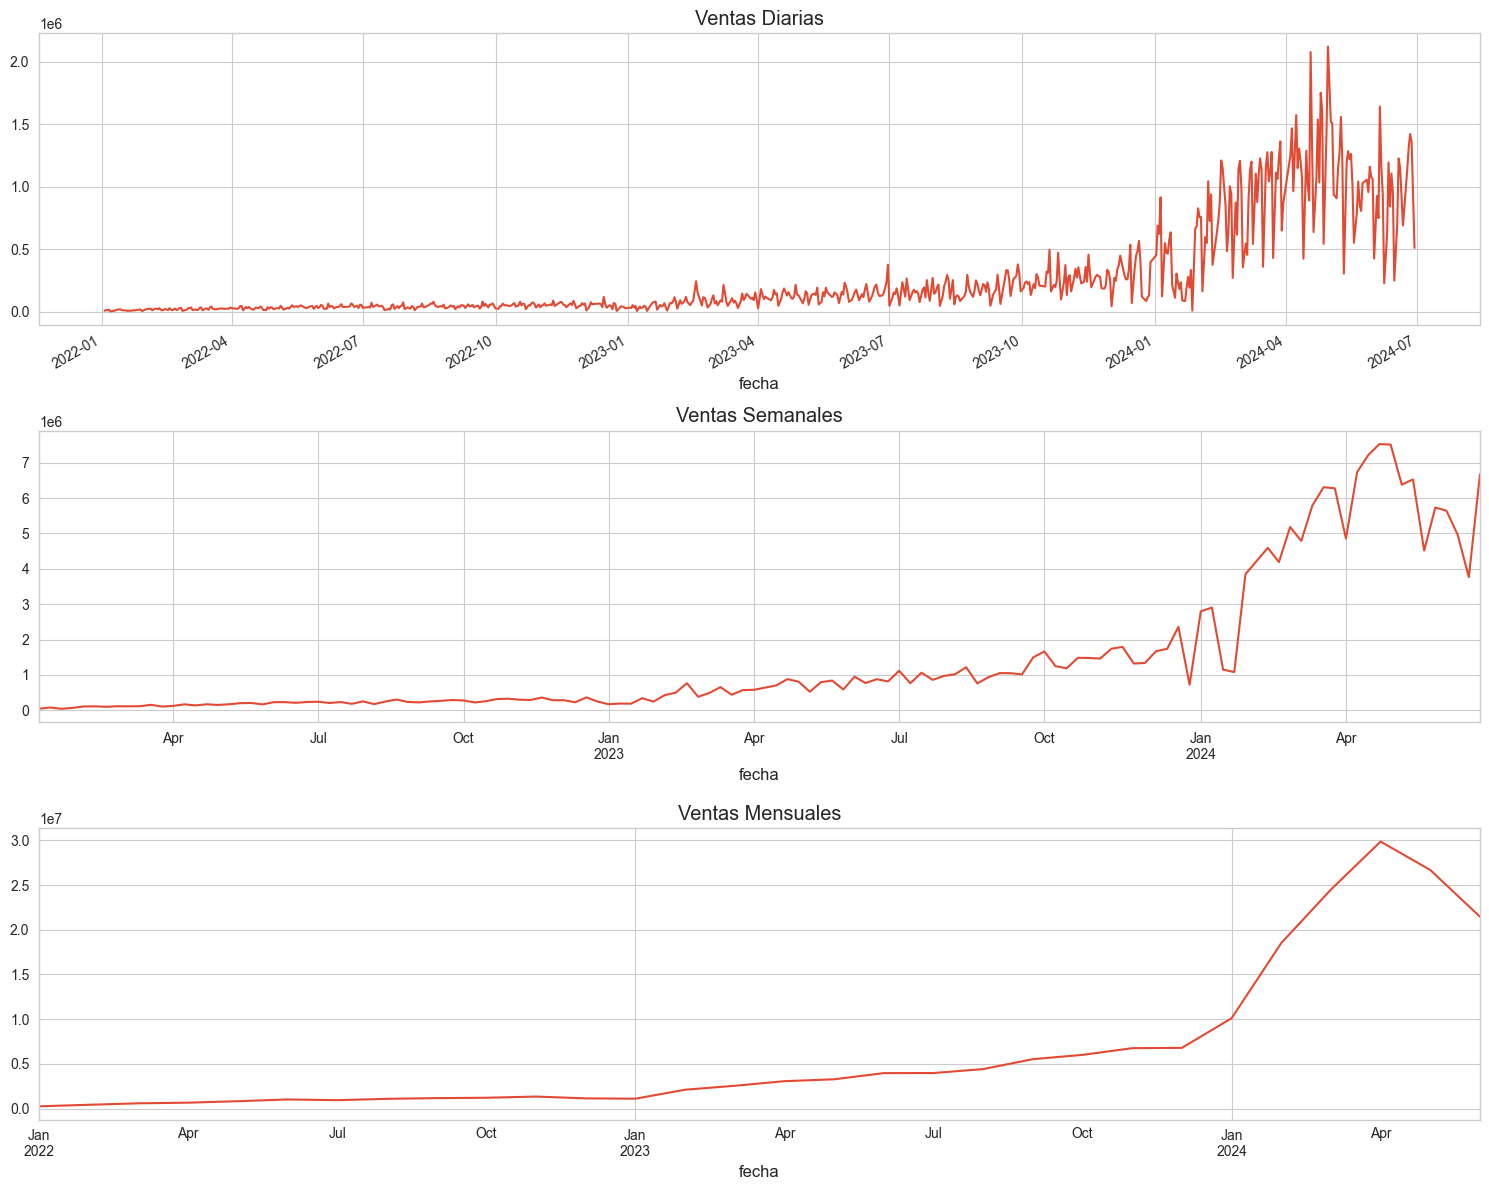

In [41]:
# Agrupación diaria
diario = df_viz_desc.groupby('fecha')['precio_total'].sum()

# Agrupación semanal
semanal = df_viz_desc.groupby(pd.Grouper(key='fecha', freq='W'))['precio_total'].sum()

# Agrupación mensual
mensual = df_viz_desc.groupby(pd.Grouper(key='fecha', freq='ME'))['precio_total'].sum()

# Visualización comparativa
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

diario.plot(ax=axes[0], title='Ventas Diarias')
semanal.plot(ax=axes[1], title='Ventas Semanales')
mensual.plot(ax=axes[2], title='Ventas Mensuales')

plt.tight_layout()
plt.show()

In [42]:

df['fecha_alta_solo_fecha'] = df['fecha_alta'].dt.date

diferencias = df[df['fecha'] != df['fecha_alta_solo_fecha']]

print(f"Diferencias encontradas: {len(diferencias)}")
#Se puede ver que en un 99% de los registros, nuestra fecha coincide con la fecha de alta, por lo que podemos utilizar la hora de alta como un proxy para nuestro análisis de granularidad temporal.
#Se encuentran 151 diferencias entre fecha y fecha_añta, pero esto es debido a que existen 151 registros que no tienen fecha_alta, pero debido a que en su gran mayoría estas coincide, en un futuro podemos rellenar estas filas vacías con lso vaores de fecha y asignar valores de media para la hora.

Diferencias encontradas: 151


In [43]:
#Esta parte será un poco capciosa
# df['hora'] = df['fecha_alta].dt.hour# El campo fecha NO TIENE la hora, tomaremos la hora de fecha alta como proxy

df_viz_desc['hora'] = df_viz_desc['fecha_alta'].dt.hour

# Calculamos la media de horas no nulas
hora_media = int(df_viz_desc['hora'].dropna().mean())

# Función para completar fecha_alta faltante
def completar_fecha_regis(row):
    if pd.isna(row['fecha_alta']):
        # Combinar la fecha de 'fecha' con la hora media para formar un datetime
        fecha_sin_hora = row['fecha']
        return pd.Timestamp(year=fecha_sin_hora.year,
                            month=fecha_sin_hora.month,
                            day=fecha_sin_hora.day,
                            hour=hora_media)
    else:
        return row['fecha_alta']


df_viz_desc['fecha_alta'] = df_viz_desc.apply(completar_fecha_regis, axis=1)



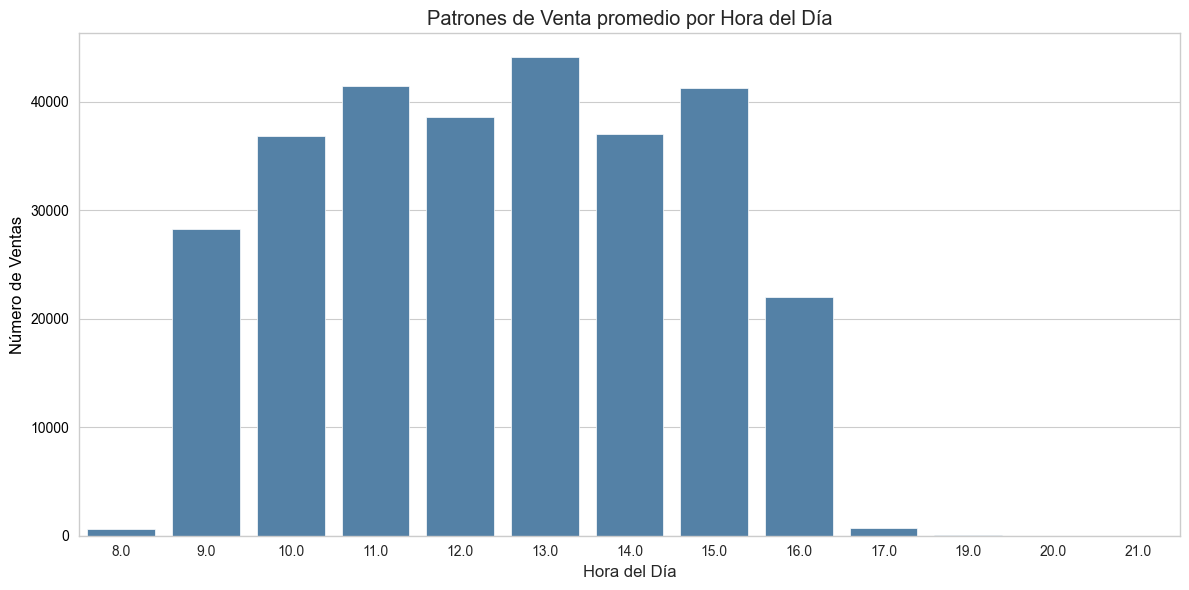

In [44]:
# Agrupación por hora
ventas_hora = df_viz_desc.groupby('hora')['precio_total'].agg(['mean', 'count']).reset_index()  

# Crear figura y eje doble
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(x='hora', y='count', data=ventas_hora, ax=ax1, color='steelblue')
ax1.set_ylabel("Número de Ventas", color='black')
ax1.set_xlabel("Hora del Día")
ax1.tick_params(axis='y', labelcolor='black')


# Título y ajustes finales
plt.title("Patrones de Venta promedio por Hora del Día")
plt.tight_layout()
plt.show()



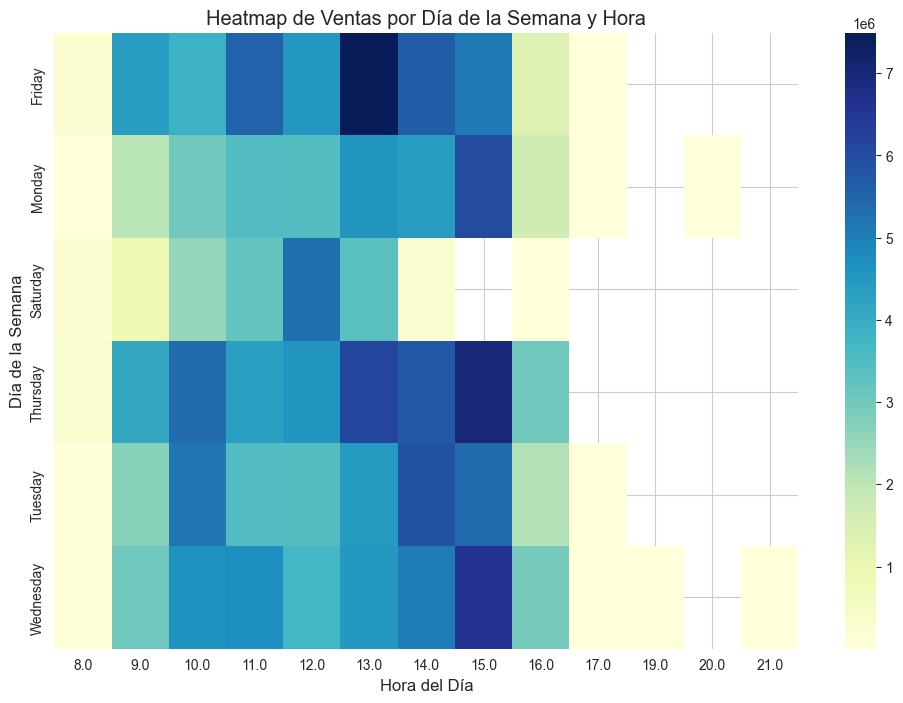

In [45]:
# Heatmap de Ventas (Día de la Semana vs Hora)
pivot_table = df_viz_desc.pivot_table(
    index='dia_semana',
    columns='hora',
    values='precio_total',
    aggfunc='sum'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, cmap="YlGnBu") 
plt.title('Heatmap de Ventas por Día de la Semana y Hora')
plt.xlabel('Hora del Día')
plt.ylabel('Día de la Semana')
plt.show()



### 5.2 Análisis de valores faltantes de ventas por índice temporal

Para determinar la granularidad temporal más apropiada para hacer predicciones de venta por producto, necesitamos lograr un equilibrio entre:

1. **Resolución temporal**: Mayor granularidad = más datos para el modelo
2. **Completitud de datos**: Menos valores faltantes = series más robustas

In [46]:
# tablas pivot de ventas por producto y periodo

#indifetrente si se trabaja con precio_total, canti_venta, canti, etc
# diario
pivot_diario = df_viz_desc.pivot_table(index='fecha', columns='descrip', values='precio_total', aggfunc='sum')
# semanal
pivot_semanal = df_viz_desc.groupby([pd.Grouper(key='fecha', freq='W'), 'descrip'])['precio_total'].sum().unstack('descrip')
# mensual
pivot_mensual = df_viz_desc.groupby([pd.Grouper(key='fecha', freq='ME'), 'descrip'])['precio_total'].sum().unstack('descrip')

# Rellenar índices faltantes para asegurar continuidad en cada frecuencia
idx_diario   = pd.date_range(df_viz_desc['fecha'].min(), df_viz_desc['fecha'].max(), freq='D')
idx_semanal  = pd.date_range(df_viz_desc['fecha'].min(), df_viz_desc['fecha'].max(), freq='W')
idx_mensual  = pd.date_range(df_viz_desc['fecha'].min(), df_viz_desc['fecha'].max(), freq='ME')
pivot_diario   = pivot_diario.reindex(idx_diario)
pivot_semanal  = pivot_semanal.reindex(idx_semanal)
pivot_mensual  = pivot_mensual.reindex(idx_mensual)

#valores faltantes por producto y porc
def calcular_faltantes(pivot, nombre):
    total_periodos = pivot.shape[0]
    faltantes = pivot.isna().sum()
    pct_faltantes = faltantes / total_periodos * 100
    return pd.DataFrame({
        f'faltantes_count_{nombre}': faltantes,
        f'faltantes_pct_{nombre}': pct_faltantes
    })

stats_diario  = calcular_faltantes(pivot_diario,  'diario')
stats_semanal = calcular_faltantes(pivot_semanal, 'semanal')
stats_mensual = calcular_faltantes(pivot_mensual, 'mensual')

# Consolidar y ordenar estadísticas
stats_faltantes = (
    stats_diario
    .join(stats_semanal)
    .join(stats_mensual)
    .reset_index()
    .rename(columns={'index': 'descrip'})
    .sort_values('faltantes_count_diario')
    .reset_index(drop=True)
)
display(stats_faltantes)


,descrip,faltantes_count_diario,faltantes_pct_diario,faltantes_count_semanal,faltantes_pct_semanal,faltantes_count_mensual,faltantes_pct_mensual
0,opera x 55 grs.,239,26.292629,0,0.000000,0,0.000000
1,mogul rollo x 12 uds.,253,27.832783,0,0.000000,0,0.000000
2,opera x 92 grs.,257,28.272827,0,0.000000,0,0.000000
3,oblea bon o bon leche x 30 grs.,264,29.042904,1,0.775194,0,0.000000
4,saladix jamon x 30 grs.,271,29.812981,1,0.775194,0,0.000000
...,...,...,...,...,...,...,...
3627,lc mer +f naranaj,908,99.889989,128,99.224806,28,96.551724
3628,lc mer aranada,908,99.889989,128,99.224806,28,96.551724
3629,aass surt bagley,908,99.889989,128,99.224806,28,96.551724
3630,ws rock-tromp-mast-choc,908,99.889989,128,99.224806,28,96.551724


In [47]:

# 3) Tablas ordenadas de faltantes % de menor a mayor
faltantes_mensual = stats_faltantes[['descrip', 'faltantes_pct_mensual']].sort_values('faltantes_pct_mensual')
faltantes_semanal = stats_faltantes[['descrip', 'faltantes_pct_semanal']].sort_values('faltantes_pct_semanal')
faltantes_diario  = stats_faltantes[['descrip', 'faltantes_pct_diario']].sort_values('faltantes_pct_diario')

display(faltantes_mensual)
display(faltantes_semanal)
display(faltantes_diario)




,descrip,faltantes_pct_mensual
16,serranitas arcor 3 x 105 grs.,0.0
15,choc. celofan blanco x 25 grs.,0.0
18,saladix jamon x 100 grs.,0.0
51,mogul tiburoncitos x 12 uds.,0.0
69,mentho plus menthol x 12 uds.,0.0
...,...,...
3591,traviata balance,100.0
3592,traviata balance x 321 grs.,100.0
3457,gelato13959,100.0
3504,h. palito mogul x 18 uds.,100.0


,descrip,faltantes_pct_semanal
36,menta cristal x 810 grs.,0.0
1,mogul rollo x 12 uds.,0.0
0,opera x 55 grs.,0.0
7,sonrisas frambuesa x 108 grs.,0.0
2,opera x 92 grs.,0.0
...,...,...
3207,bol. rodajas acidas,100.0
3451,mentho plus x 12 menthol,100.0
3558,alf tofi negro 40g,100.0
3504,h. palito mogul x 18 uds.,100.0


,descrip,faltantes_pct_diario
0,opera x 55 grs.,26.292629
1,mogul rollo x 12 uds.,27.832783
2,opera x 92 grs.,28.272827
3,oblea bon o bon leche x 30 grs.,29.042904
4,saladix jamon x 30 grs.,29.812981
...,...,...
3627,lc mer +f naranaj,99.889989
3628,lc mer aranada,99.889989
3629,aass surt bagley,99.889989
3630,ws rock-tromp-mast-choc,99.889989


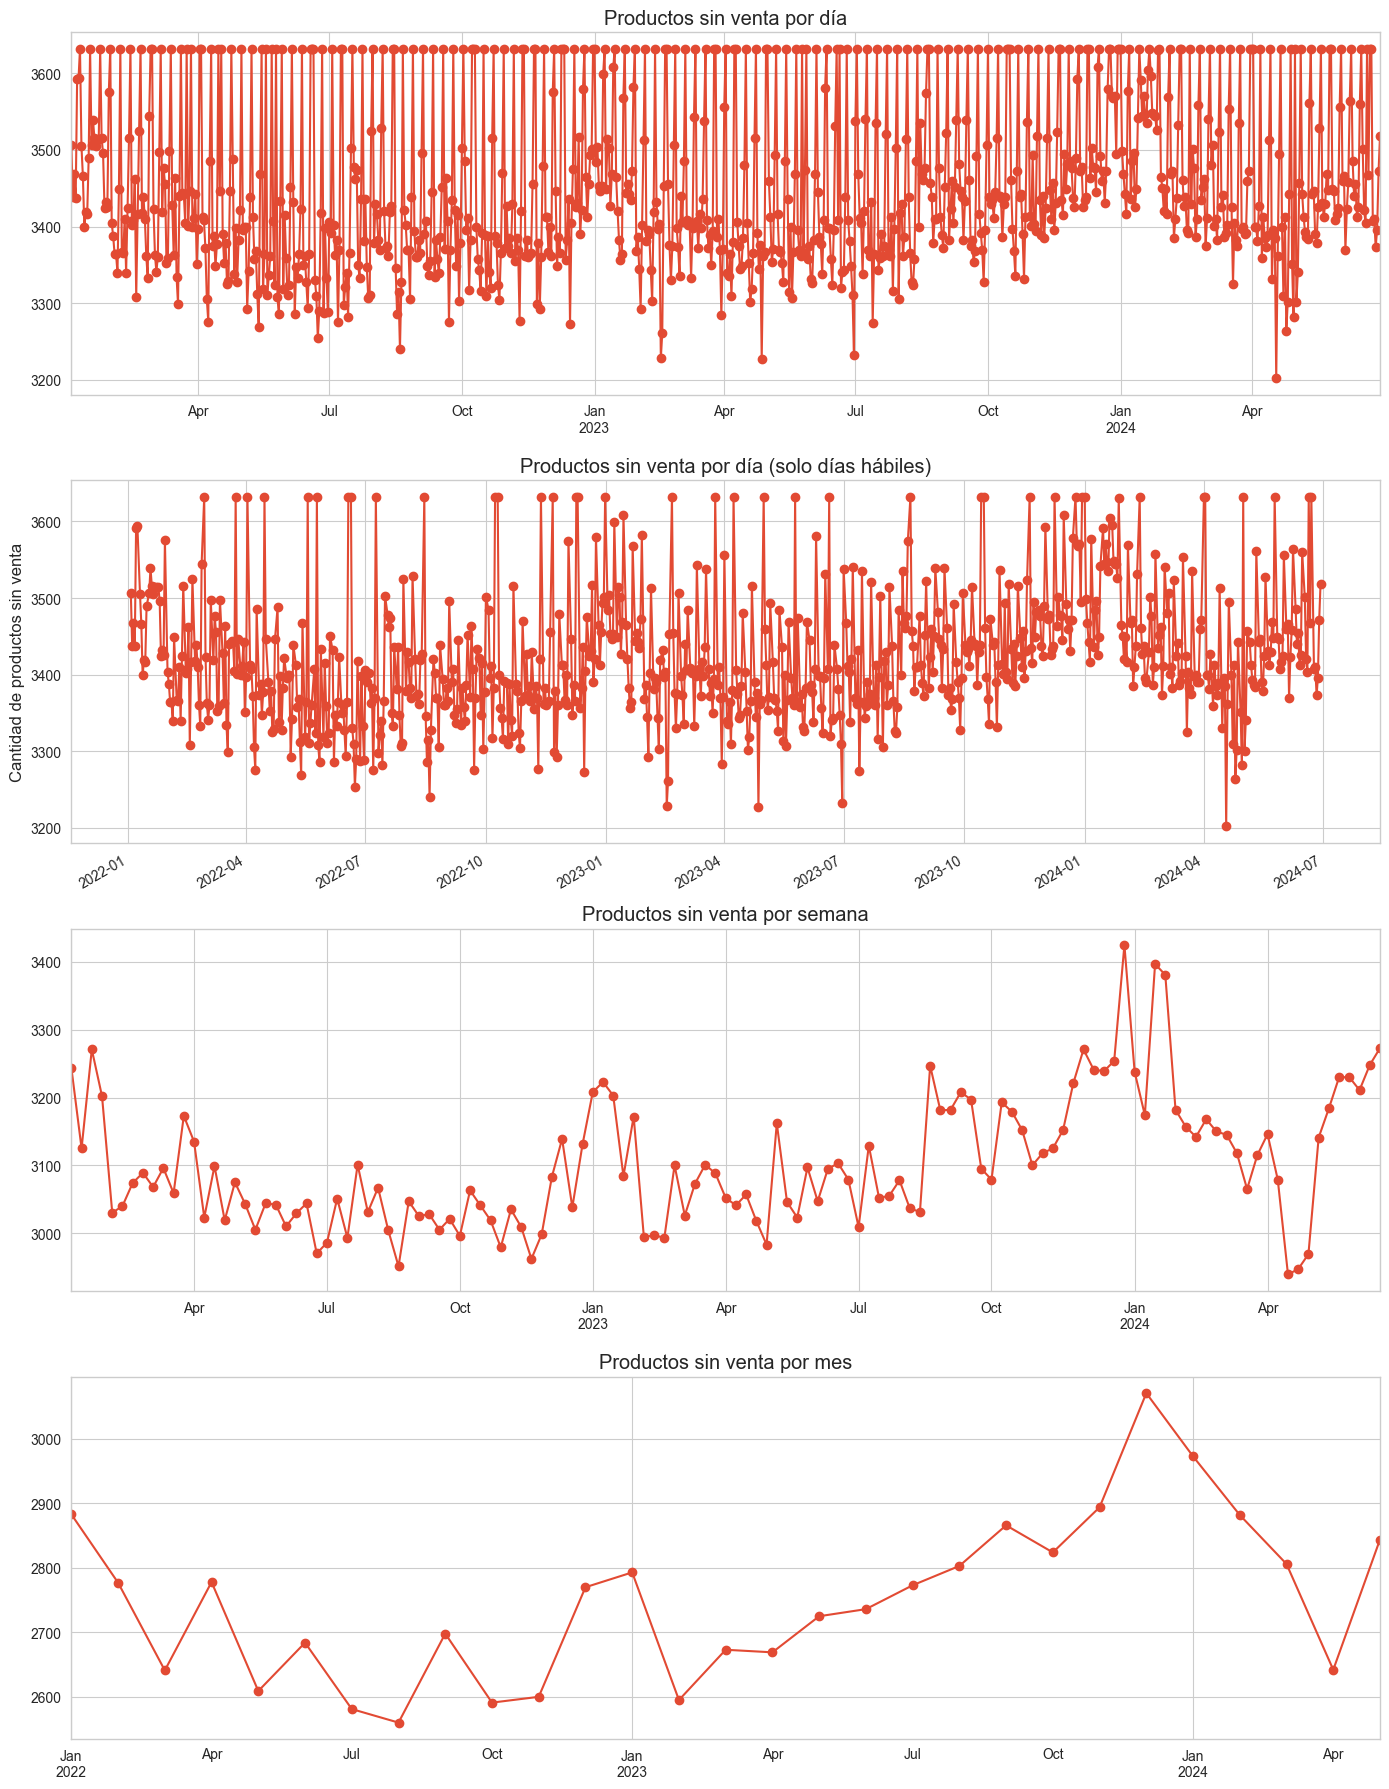

In [48]:
    faltantes_periodo_diario  = pivot_diario.isna().sum(axis=1)
    faltantes_periodo_semanal = pivot_semanal.isna().sum(axis=1)
    faltantes_periodo_mensual = pivot_mensual.isna().sum(axis=1)

    #gráficos de frecuencia de valores faltantes
    fig, axes = plt.subplots(4, 1, figsize=(14, 18))

    # Diario
    faltantes_periodo_diario.plot(ax=axes[0], marker='o')
    axes[0].set_title('Productos sin venta por día')

    # Diario solo días laborales
    dias_laborales = faltantes_periodo_diario[faltantes_periodo_diario.index.dayofweek < 6] #Ver si tomamos el sábado o no
    dias_laborales.plot(ax=axes[1], marker='o')
    axes[1].set_title('Productos sin venta por día (solo días hábiles)')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Cantidad de productos sin venta')


    #smeanal
    faltantes_periodo_semanal.plot(ax=axes[2], marker='o')
    axes[2].set_title('Productos sin venta por semana')

    #mensual
    faltantes_periodo_mensual.plot(ax=axes[3], marker='o')
    axes[3].set_title('Productos sin venta por mes')

    plt.tight_layout()
    plt.show()


#### Analisis de Clientes

567


C:\Users\marti\AppData\Local\Temp\ipykernel_16564\810755374.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




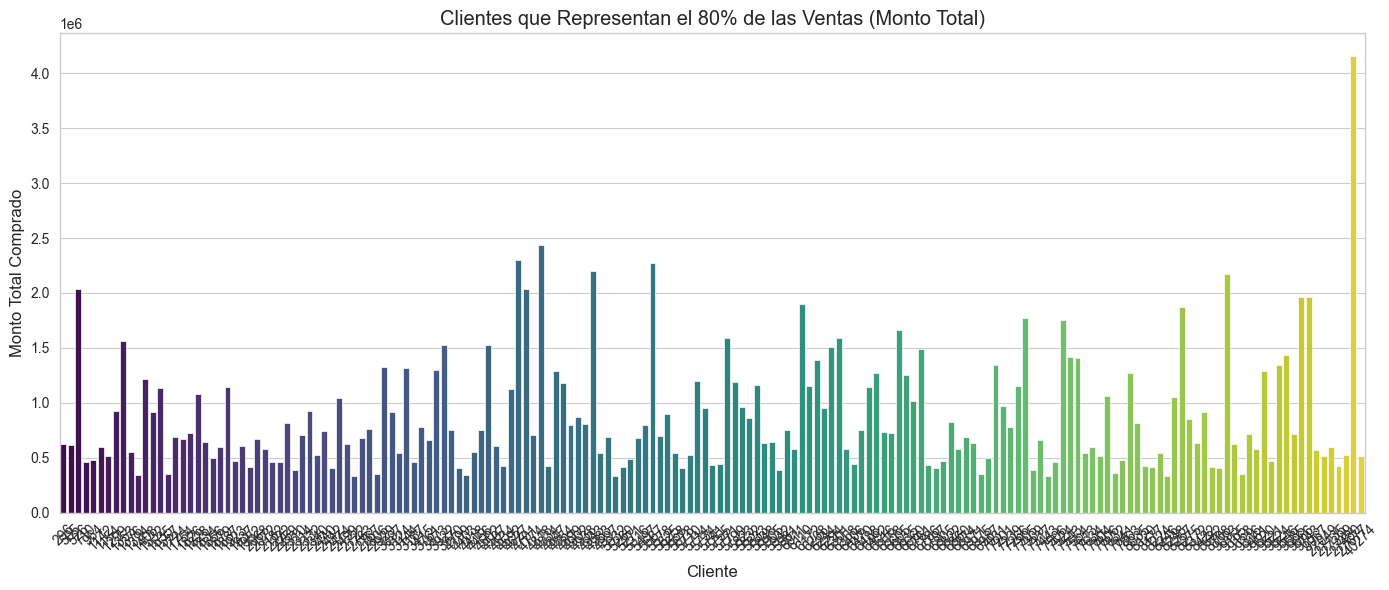

In [49]:
# veamos la cantidad de clientes diferentes
print(len(df_viz_desc.cliente.unique()))

# veamos la cantidad de compras por cada cliente (montos)
# Calcular total vendido por cliente
ventas_por_cliente = df_viz_desc.groupby('cliente')['precio_total'].sum().sort_values(ascending=False)

# Porcentaje acumulado
ventas_acum_pct = ventas_por_cliente.cumsum() / ventas_por_cliente.sum()

# Clientes que conforman el 80% de las ventas
clientes_80_ventas = ventas_acum_pct[ventas_acum_pct <= 0.80].index

# Filtrar los datos
ventas_80_df = ventas_por_cliente.loc[clientes_80_ventas]

# Graficar
plt.figure(figsize=(14, 6))
sns.barplot(x=ventas_80_df.index, y=ventas_80_df.values, palette='viridis')
plt.title('Clientes que Representan el 80% de las Ventas (Monto Total)')
plt.xlabel('Cliente')
plt.ylabel('Monto Total Comprado')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\marti\AppData\Local\Temp\ipykernel_16564\496765917.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




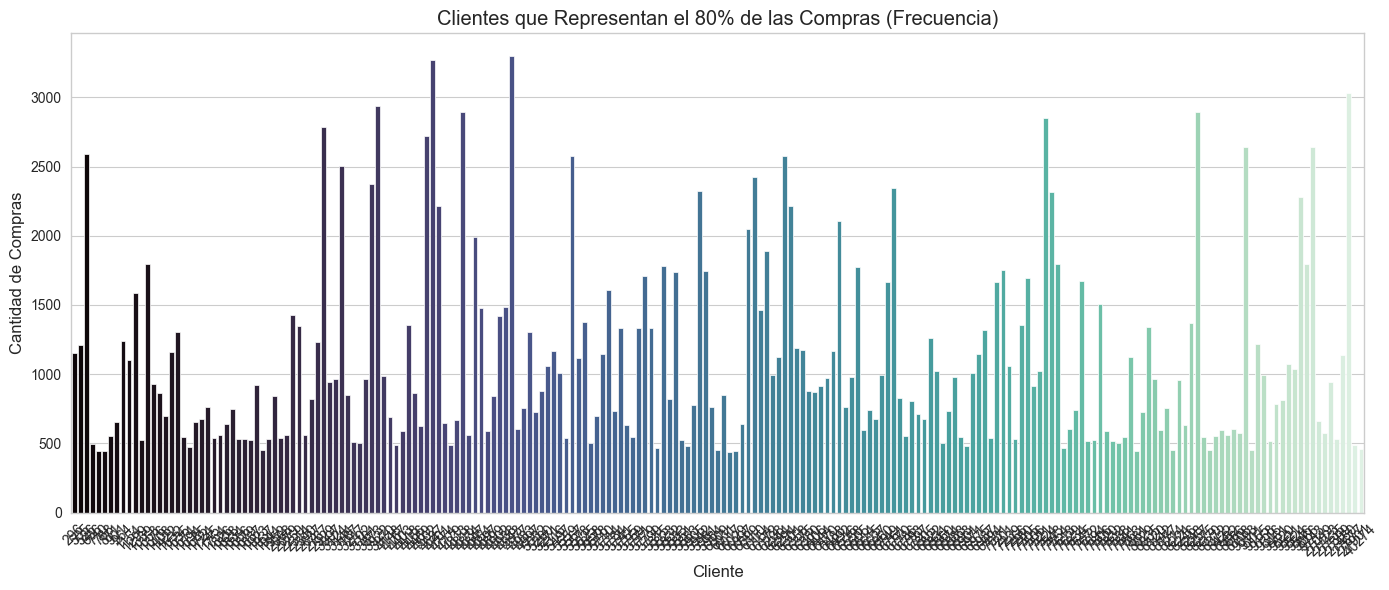

In [50]:
# Calcular frecuencia de compras por cliente
frecuencia_por_cliente = df_viz_desc['cliente'].value_counts()

# Porcentaje acumulado
frecuencia_acum_pct = frecuencia_por_cliente.cumsum() / frecuencia_por_cliente.sum()

# Clientes que conforman el 80% de las compras
clientes_80_frecuencia = frecuencia_acum_pct[frecuencia_acum_pct <= 0.80].index

# Filtrar
frecuencia_80_df = frecuencia_por_cliente.loc[clientes_80_frecuencia]

# Graficar
plt.figure(figsize=(14, 6))
sns.barplot(x=frecuencia_80_df.index, y=frecuencia_80_df.values, palette='mako')
plt.title('Clientes que Representan el 80% de las Compras (Frecuencia)')
plt.xlabel('Cliente')
plt.ylabel('Cantidad de Compras')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
length_clients_monto = len(clientes_80_ventas)
length_clients_freq  = len(clientes_80_frecuencia)
print("Número de clientes con el 80% del monto:", length_clients_monto)
print("Número de clientes con el 80% de la frecuencia:", length_clients_freq)

Número de clientes con el 80% del monto: 175
Número de clientes con el 80% de la frecuencia: 213


### 5.3 Análisis de valores faltantes en ventas por sucursal y por índice temporal

Hacemos el mismo análisis pero ahora por Sucursal

In [52]:
# Hacemos lo mismo pero segregando por sucursal
# definir índices para cada frecuencia
idx_d = pd.date_range(df_viz_desc['fecha'].min(), df['fecha'].max(), freq='D')
idx_w = pd.date_range(df_viz_desc['fecha'].min(), df['fecha'].max(), freq='W')
idx_m = pd.date_range(df_viz_desc['fecha'].min(), df['fecha'].max(), freq='ME')

# calcular faltantes y porcentajes por sucursal y frecuencia
branches = sorted(df['sucur'].unique())
stats = []
for s in branches:
    d = (df_viz_desc[df_viz_desc['sucur']==s].groupby('fecha')['precio_total'].sum().reindex(idx_d))
    w = (df_viz_desc[df_viz_desc['sucur']==s].groupby(pd.Grouper(key='fecha', freq='W'))['precio_total'].sum().reindex(idx_w))
    m = (df_viz_desc[df_viz_desc['sucur']==s].groupby(pd.Grouper(key='fecha', freq='ME'))['precio_total'].sum().reindex(idx_m))
    stats.append({
        'sucur': s,
        'falt_count_diario': d.isna().sum(),
        'falt_pct_diario': d.isna().mean()*100,
        'falt_count_semanal': w.isna().sum(),
        'falt_pct_semanal': w.isna().mean()*100,
        'falt_count_mensual': m.isna().sum(),
        'falt_pct_mensual': m.isna().mean()*100,
    })

stats_df = pd.DataFrame(stats).sort_values('falt_count_diario')
display(stats_df)



,sucur,falt_count_diario,falt_pct_diario,falt_count_semanal,falt_pct_semanal,falt_count_mensual,falt_pct_mensual
0,1,265,29.152915,16,12.403101,3,10.344828
1,9,515,56.655666,0,0.000000,0,0.000000
2,12,811,89.218922,112,86.821705,26,89.655172


Visualizamos por sucursal en base a los días operativos de las mismas (ya que partimos de la hipotesis de que no todas las sucursales operan desde el mismo periodo de tiempo)

In [53]:
# Calcular rango de fechas por sucursal
fechas_por_sucursal = df_viz_desc.groupby('sucur')['fecha'].agg(['min', 'max'])
fechas_por_sucursal['dias_totales'] = (fechas_por_sucursal['max'] - fechas_por_sucursal['min']).dt.days + 1

# Calcular días con datos por sucursal
dias_con_datos = df_viz_desc.groupby('sucur')['fecha'].nunique().rename('dias_con_datos')

# Unir ambos
fechas_por_sucursal = fechas_por_sucursal.join(dias_con_datos)
fechas_por_sucursal['porcentaje_dias_con_datos'] = 100 * fechas_por_sucursal['dias_con_datos'] / fechas_por_sucursal['dias_totales']

# Mostrar resultado ordenado
fechas_por_sucursal = fechas_por_sucursal.sort_values('min')
display(fechas_por_sucursal)


,min,max,dias_totales,dias_con_datos,porcentaje_dias_con_datos
sucur,,,,,
1,2022-01-03,2024-02-29,788,644,81.725888
9,2022-01-08,2024-06-29,904,394,43.584071
12,2024-03-01,2024-06-29,121,98,80.991736


Como podemos ver, la sucursal 1 y 9 son las que más datos tienen, mientras que la sucursal 12 tiene una cantidad de datos muy baja.

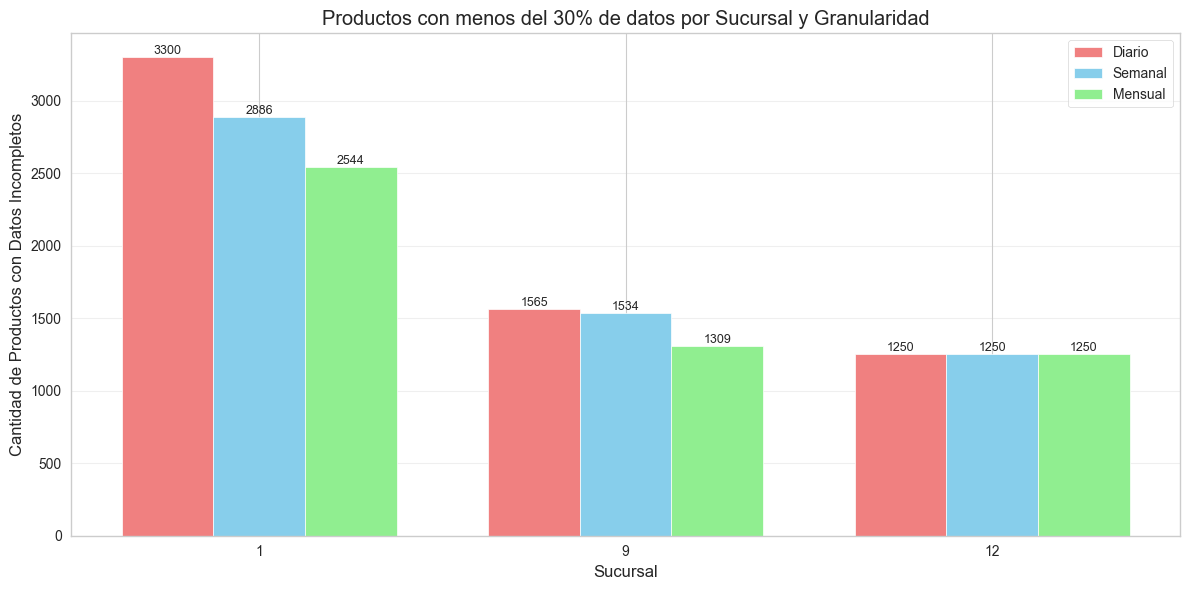


RESUMEN: Productos con menos del 30% de datos completos


,Total_Productos,Diario,Semanal,Mensual,%_Diario,%_Semanal,%_Mensual
Sucursal,,,,,,,
1,3425,3300,2886,2544,96.4,84.3,74.3
9,1565,1565,1534,1309,100.0,98.0,83.6
12,1250,1250,1250,1250,100.0,100.0,100.0


In [54]:
# Análisis de productos con datos incompletos por sucursal y granularidad temporal para entender nuestro potencial predictivo x producto y sucursal.
def analizar_productos_incompletos(df, umbral=0.7):
    """
    Analiza cuántos productos por sucursal no cumplen con el umbral mínimo de datos
    para cada granularidad temporal (diaria, semanal, mensual)
    """

    idx_diario = pd.date_range(df_viz_desc['fecha'].min(), df['fecha'].max(), freq='D')
    idx_semanal = pd.date_range(df_viz_desc['fecha'].min(), df['fecha'].max(), freq='W')
    idx_mensual = pd.date_range(df_viz_desc['fecha'].min(), df['fecha'].max(), freq='ME')
    
    sucursales = sorted(df['sucur'].unique())
    resultados = []
    
    for sucur in sucursales:
        df_sucur = df_viz_desc[df_viz_desc['sucur'] == sucur]
        
        # tablas pivot
        pivot_d = df_sucur.pivot_table(index='fecha', columns='descrip', values='precio_total', aggfunc='sum').reindex(idx_diario)
        pivot_s = df_sucur.groupby([pd.Grouper(key='fecha', freq='W'), 'descrip'])['precio_total'].sum().unstack('descrip').reindex(idx_semanal)
        pivot_m = df_sucur.groupby([pd.Grouper(key='fecha', freq='ME'), 'descrip'])['precio_total'].sum().unstack('descrip').reindex(idx_mensual)
        
        #Calculamos porcentaje de datos completos -dada la granularidad- por producto
        pct_datos_d = (1 - pivot_d.isna().mean()) 
        pct_datos_s = (1 - pivot_s.isna().mean()) 
        pct_datos_m = (1 - pivot_m.isna().mean()) 
        
        # Chequeamos y contamos aquellos productos que no cumplen con el umbral mínimo
        productos_incompletos_d = (pct_datos_d < umbral).sum()
        productos_incompletos_s = (pct_datos_s < umbral).sum()
        productos_incompletos_m = (pct_datos_m < umbral).sum()
        
        total_productos = df_sucur['descrip'].nunique()
        
        resultados.append({
            'Sucursal': sucur,
            'Total_Productos': total_productos,
            'Diario': productos_incompletos_d,
            'Semanal': productos_incompletos_s,
            'Mensual': productos_incompletos_m
        })
    
    return pd.DataFrame(resultados)


#####################
## Umbral mínimo de datos completos dada la granularidad temporal.
## Abajo encontraremos un gráfico y una tabla que enumeran la cantidad de productos por sucursal que, 
## dada una granularidad temporal (diaria, semanal, mensual), no llegan al umbral mínimo de datos completos.
umbral = 0.3
df_incompletos = analizar_productos_incompletos(df_viz_desc, umbral)


fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_incompletos))
width = 0.25

bars1 = ax.bar(x - width, df_incompletos['Diario'], width, label='Diario', color='lightcoral')
bars2 = ax.bar(x, df_incompletos['Semanal'], width, label='Semanal', color='skyblue')
bars3 = ax.bar(x + width, df_incompletos['Mensual'], width, label='Mensual', color='lightgreen')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Sucursal')
ax.set_ylabel('Cantidad de Productos con Datos Incompletos')
ax.set_title(f'Productos con menos del {umbral*100:.0f}% de datos por Sucursal y Granularidad')
ax.set_xticks(x)
ax.set_xticklabels(df_incompletos['Sucursal'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


print(f"\nRESUMEN: Productos con menos del {umbral*100:.0f}% de datos completos")
print("=" * 60)

df_resumen = df_incompletos.copy()
df_resumen['%_Diario'] = (df_resumen['Diario'] / df_resumen['Total_Productos'] * 100).round(1)
df_resumen['%_Semanal'] = (df_resumen['Semanal'] / df_resumen['Total_Productos'] * 100).round(1)
df_resumen['%_Mensual'] = (df_resumen['Mensual'] / df_resumen['Total_Productos'] * 100).round(1)

display(df_resumen.set_index('Sucursal'))

**Consideración sobre la Granularidad Temporal**:

Del análisis de las granularidades temporales se desprende, a priori, que muchos productos presentan una magnitud considerable de datos faltantes al agrupar sus ventas en las temporalidades analizadas (D, S y M). Considerando que nuestro propósito es entrenar un modelo de predicción de ventas por productos, esto anticipa una potencial situación problemática.

Es probable que debamos realizar una selección de los productos más vendidos por cada sucursal y ajustar la elección de la granularidad temporal a dichos casos particulares. Esto nos permitirá maximizar el impacto potencial de nuestras predicciones en la medida en que brindaría la posibilidad de contar con un mejor modelo predictivo (menor cantidad de valores faltantes ---> mayor granularidad ---> serie más robusta) concentrado en los productos con mayor repercusión (los más vendidos).

## 7. Hipótesis y Hallazgos



**Estructura y Volumen del Dataset**
*   **Dimensiones**: 310,217 transacciones registradas con 52 variables numéricas (35) y categóricas (17).
*   **Período temporal**: 3-ene-2022 al 29-jun-2024 
*   **Sucursales**: 3 sucursales operativas (códigos 1, 9, 12)
*   **Catálogo**: 3,808 productos únicos distribuidos heterogéneamente entre sucursales

    
**Calidad de los Datos**
*   **Completitud alta**: Solo 3 columnas superan 10% de nulos (`depo`, `orden_compra_nume`, `origen_pedido`)
*   **Escalas normalizadas**: Variables monetarias y de cantidad fueron deflactadas y normalizadas (división por 1M)
*   **Cobertura temporal consistente**:  Campos fecha, entre\_fecha, fecha\_regis, fecha\_alta muestran rangos de 908-911 días sin huecos evidentes; la serie es apta para modelos de demanda.    
*   **Tratamiento de outliers**: Se aplicó filtrado por percentiles (P1-P99) en variables numéricas clave (`total`, `iva1`, `canti_venta`, `precio_uni`) para remover valores extremos que podrían sesgar el análisis. Esta estrategia conserva el 98% de las observaciones mientras elimina anomalías potenciales. La política es revisable según los objetivos específicos de modelado futuro.
*   **Variables redundantes** Campos \_ori, \_precio, linea\_nume\_auxi, secuen tienen correlación 1 : 1 con sus equivalentes y pueden eliminarse, reduciendo el tamaño del dataset ~35 %.


**Patrones de Negocio Identificados**
*   **Concentración de productos**: Solo 131 productos (3.44% del catálogo) representan el 80% del volumen de ventas.
*   **Diferencias por sucursal**: 
    - Sucursal 1 domina en facturación
    - Distribución desigual de productos entre puntos de venta
*   **Tendencia temporal**: Crecimiento sostenido con aceleración marcada desde 2024
*   **Patrones estacionales**: Potencial ciclo mensual/quincenal, ausencia de estacionalidad anual marcada.
*   **Método de pago dominante**: `condi_venta='00'` (contado) en ~78% de transacciones (posible asimilación de frecuenci).


**Estructura del negocio**       
*   **Facturación total:** $452,332,265
*   **Ticket promedio:** $11,054
*   **Ticket mediano:** $4,807
*   **Clientes únicos:** 566 clientes
*   **Promedio de transacciones por dí:** 42.5 transacciones/día
*   **Ventas Mayoristas (A):** 86.91%
*   **Ventas Minoristas (B):** 13.09%

*   **Método de pago dominante** condi\_venta='00' (contado) representa 78 % de transacciones; ventas financiadas (07, mp, 14) muestran tickets 18 % mayores, oportunidad para impulsar cuotas.
    
*   **Concentración de productos por sucursal:** 

                Sucursal 9:
                • Productos que explican 80 % de unidades: 105
                • Porcentaje de SU catálogo: 6.78%

                Sucursal 1:
                • Productos que explican 80 % de unidades: 134
                • Porcentaje de SU catálogo: 4.00%

                Sucursal 12:
                • Productos que explican 80 % de unidades: 127
                • Porcentaje de SU catálogo: 10.13%
    



# TP2 - Análisis Exploratorio y Curación de Datos

## 1. Definicion de Granularidad Principal

Gracias al análisis hecho en el inciso 5.2 y 5.3 del TP1 pudimos ver que con la perspectiva mensual tenemos menos cantidad de datos faltantes en las series de cada producto, tanto para el total como para cada sucursal por separado.

**Para aportar a esta investigación vamos a restringir esta mirada a los productos más vendidos (los productos que hacen el 80% de las ventas).**

### 1.1 Análisis de valores faltantes de ventas por índice temporal

In [55]:
df_find_gran = df_viz_desc.copy()

# 1. Identificar productos Pareto (20% que hacen 80% de nuestra FACTURACIÓN, a diferencia de los paretos de cantidad de ventas vistos anteriormente)
ventas_por_producto = df_find_gran.groupby('descrip')['precio_total'].sum().sort_values(ascending=False)
ventas_acumuladas = ventas_por_producto.cumsum()
porcentaje_acumulado = ventas_acumuladas / ventas_por_producto.sum() * 100

# Encontrar productos que representan ~80% de las ventas
productos_pareto = ventas_por_producto[porcentaje_acumulado <= 80].index.tolist()
n_productos_pareto = len(productos_pareto)
porcentaje_productos = (n_productos_pareto / len(ventas_por_producto)) * 100

# 2. Crear df_pareto filtrado
df_pareto = df_find_gran[df_find_gran['descrip'].isin(productos_pareto)].copy()

print(f" {porcentaje_productos:.1f}% de productos ({n_productos_pareto} productos) explican el 80% de la facturación total.")

 10.2% de productos (369 productos) explican el 80% de la facturación total.


Analizamos ahora la completitud de las series y evaluamos qué granularidad temporal es más estable

In [56]:
# tablas pivot de ventas por producto y periodo

#indifetrente si se trabaja con precio_total, canti_venta, canti, etc
# diario
pivot_diario = df_pareto.pivot_table(index='fecha', columns='descrip', values='precio_total', aggfunc='sum')
# semanal
pivot_semanal = df_pareto.groupby([pd.Grouper(key='fecha', freq='W'), 'descrip'])['precio_total'].sum().unstack('descrip')
# mensual
pivot_mensual = df_pareto.groupby([pd.Grouper(key='fecha', freq='ME'), 'descrip'])['precio_total'].sum().unstack('descrip')

# Rellenar índices faltantes para asegurar continuidad en cada frecuencia
idx_diario   = pd.date_range(df_pareto['fecha'].min(), df_pareto['fecha'].max(), freq='D')
idx_semanal  = pd.date_range(df_pareto['fecha'].min(), df_pareto['fecha'].max(), freq='W')
idx_mensual  = pd.date_range(df_pareto['fecha'].min(), df_pareto['fecha'].max(), freq='ME')
pivot_diario   = pivot_diario.reindex(idx_diario)
pivot_semanal  = pivot_semanal.reindex(idx_semanal)
pivot_mensual  = pivot_mensual.reindex(idx_mensual)

#valores faltantes por producto y porc
def calcular_faltantes(pivot, nombre):
    total_periodos = pivot.shape[0]
    faltantes = pivot.isna().sum()
    pct_faltantes = faltantes / total_periodos * 100
    return pd.DataFrame({
        f'faltantes_count_{nombre}': faltantes,
        f'faltantes_pct_{nombre}': pct_faltantes
    })

stats_diario  = calcular_faltantes(pivot_diario,  'diario')
stats_semanal = calcular_faltantes(pivot_semanal, 'semanal')
stats_mensual = calcular_faltantes(pivot_mensual, 'mensual')

# Consolidar y ordenar estadísticas
stats_faltantes = (
    stats_diario
    .join(stats_semanal)
    .join(stats_mensual)
    .reset_index()
    .rename(columns={'index': 'descrip'})
    .sort_values('faltantes_count_diario')
    .reset_index(drop=True)
)
display(stats_faltantes)


,descrip,faltantes_count_diario,faltantes_pct_diario,faltantes_count_semanal,faltantes_pct_semanal,faltantes_count_mensual,faltantes_pct_mensual
0,opera x 55 grs.,239,26.292629,0,0.000000,0,0.000000
1,mogul rollo x 12 uds.,253,27.832783,0,0.000000,0,0.000000
2,opera x 92 grs.,257,28.272827,0,0.000000,0,0.000000
3,oblea bon o bon leche x 30 grs.,264,29.042904,1,0.775194,0,0.000000
4,saladix jamon x 30 grs.,271,29.812981,1,0.775194,0,0.000000
...,...,...,...,...,...,...,...
364,alf cofler mouse,886,97.469747,119,92.248062,26,89.655172
365,arepa,888,97.689769,112,86.821705,19,65.517241
366,chocolinas 170g,889,97.799780,121,93.798450,26,89.655172
367,sonrisas 108g,890,97.909791,120,93.023256,25,86.206897


In [57]:

# 3) Tablas ordenadas de faltantes % de menor a mayor
faltantes_mensual = stats_faltantes[['descrip', 'faltantes_pct_mensual']].sort_values('faltantes_pct_mensual')
faltantes_semanal = stats_faltantes[['descrip', 'faltantes_pct_semanal']].sort_values('faltantes_pct_semanal')
faltantes_diario  = stats_faltantes[['descrip', 'faltantes_pct_diario']].sort_values('faltantes_pct_diario')

display(faltantes_mensual)
display(faltantes_semanal)
display(faltantes_diario)




,descrip,faltantes_pct_mensual
0,opera x 55 grs.,0.000000
18,saladix jamon x 100 grs.,0.000000
19,bon o bon leche x 30 uds.,0.000000
20,cofler block 38 grs.,0.000000
23,alf. tatin negro x 33 g,0.000000
...,...,...
357,cofler cookies bañadas x 132 grs.,93.103448
358,cofler cookies choco/bañada x 105.6 grs.,93.103448
349,rumba x 110 grs.,93.103448
350,cofler cookies rell bob x 85 grs.,93.103448


,descrip,faltantes_pct_semanal
0,opera x 55 grs.,0.000000
36,menta cristal x 810 grs.,0.000000
1,mogul rollo x 12 uds.,0.000000
2,opera x 92 grs.,0.000000
7,sonrisas frambuesa x 108 grs.,0.000000
...,...,...
362,h. super rocklets,93.798450
366,chocolinas 170g,93.798450
354,bob leche 30,93.798450
350,cofler cookies rell bob x 85 grs.,93.798450


,descrip,faltantes_pct_diario
0,opera x 55 grs.,26.292629
1,mogul rollo x 12 uds.,27.832783
2,opera x 92 grs.,28.272827
3,oblea bon o bon leche x 30 grs.,29.042904
4,saladix jamon x 30 grs.,29.812981
...,...,...
364,alf cofler mouse,97.469747
365,arepa,97.689769
366,chocolinas 170g,97.799780
367,sonrisas 108g,97.909791


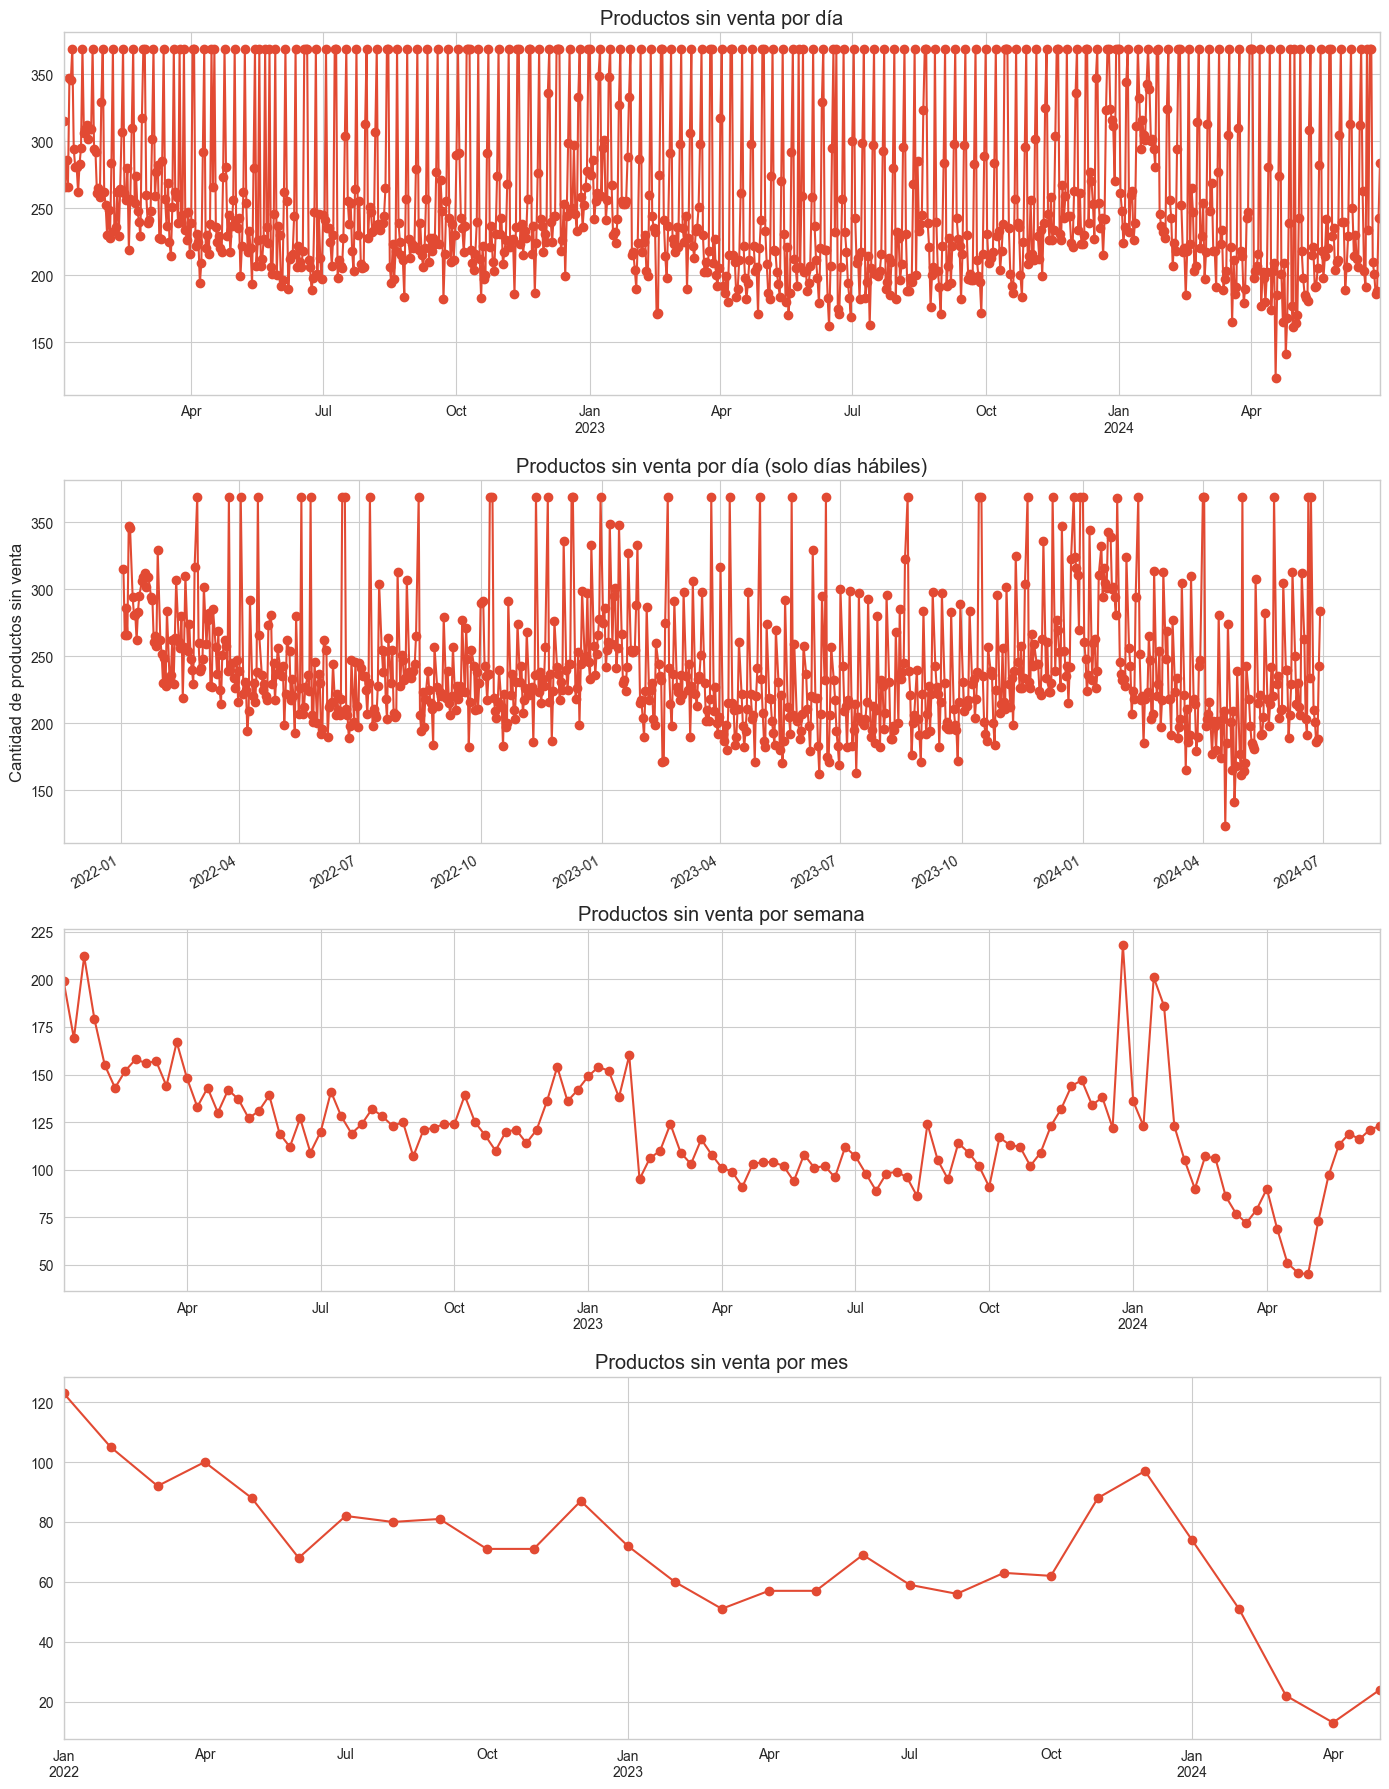

In [58]:
faltantes_periodo_diario  = pivot_diario.isna().sum(axis=1)
faltantes_periodo_semanal = pivot_semanal.isna().sum(axis=1)
faltantes_periodo_mensual = pivot_mensual.isna().sum(axis=1)

#gráficos de frecuencia de valores faltantes
fig, axes = plt.subplots(4, 1, figsize=(14, 18))

# Diario
faltantes_periodo_diario.plot(ax=axes[0], marker='o')
axes[0].set_title('Productos sin venta por día')

# Diario solo días laborales
dias_laborales = faltantes_periodo_diario[faltantes_periodo_diario.index.dayofweek < 6] #Ver si tomamos el sábado o no
dias_laborales.plot(ax=axes[1], marker='o')
axes[1].set_title('Productos sin venta por día (solo días hábiles)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Cantidad de productos sin venta')


#smeanal
faltantes_periodo_semanal.plot(ax=axes[2], marker='o')
axes[2].set_title('Productos sin venta por semana')

#mensual
faltantes_periodo_mensual.plot(ax=axes[3], marker='o')
axes[3].set_title('Productos sin venta por mes')

plt.tight_layout()
plt.show()


### 1.2 Análisis de valores faltantes en ventas por sucursal y por índice temporal

Hacemos el mismo análisis pero ahora por Sucursal

In [59]:

# PASO 1: Identificar productos Pareto por sucursal
def identificar_productos_pareto_por_sucursal(df, porcentaje_ventas=80):
    """
    Identifica productos que representan el X% de ventas en cada sucursal
    """
    productos_pareto_por_sucursal = {}
    
    for sucursal in sorted(df['sucur'].unique()):
        df_suc = df[df['sucur'] == sucursal]
        
        # Calcular ventas por producto en esta sucursal
        ventas_suc = df_suc.groupby('descrip')['precio_total'].sum().sort_values(ascending=False)
        
        # Calcular porcentaje acumulado
        ventas_acum_suc = ventas_suc.cumsum()
        pct_acum_suc = ventas_acum_suc / ventas_suc.sum() * 100
        
        # Productos que representan el X% de ventas
        productos_pareto = ventas_suc[pct_acum_suc <= porcentaje_ventas].index.tolist()
        productos_pareto_por_sucursal[sucursal] = productos_pareto
        
        print(f"Sucursal {sucursal}: {len(productos_pareto)} productos representan {porcentaje_ventas}% de la facturación")
    
    return productos_pareto_por_sucursal

# Identificar productos Pareto por sucursal
productos_pareto_dict = identificar_productos_pareto_por_sucursal(df_viz_desc, porcentaje_ventas=80)

# PASO 2: Análisis de faltantes solo para productos Pareto
# definir índices para cada frecuencia
idx_d = pd.date_range(df_viz_desc['fecha'].min(), df['fecha'].max(), freq='D')
idx_w = pd.date_range(df_viz_desc['fecha'].min(), df['fecha'].max(), freq='W')
idx_m = pd.date_range(df_viz_desc['fecha'].min(), df['fecha'].max(), freq='ME')

# calcular faltantes y porcentajes por sucursal y frecuencia (solo productos Pareto)
branches = sorted(df['sucur'].unique())
stats = []

for s in branches:
    # Filtrar por sucursal Y productos Pareto de esa sucursal
    df_sucur_pareto = df_viz_desc[
        (df_viz_desc['sucur'] == s) & 
        (df_viz_desc['descrip'].isin(productos_pareto_dict[s]))
    ]
    
    d = (df_sucur_pareto.groupby('fecha')['precio_total'].sum().reindex(idx_d))
    w = (df_sucur_pareto.groupby(pd.Grouper(key='fecha', freq='W'))['precio_total'].sum().reindex(idx_w))
    m = (df_sucur_pareto.groupby(pd.Grouper(key='fecha', freq='ME'))['precio_total'].sum().reindex(idx_m))
    
    stats.append({
        'sucur': s,
        'productos_pareto': len(productos_pareto_dict[s]),
        'falt_count_diario': d.isna().sum(),
        'falt_pct_diario': d.isna().mean()*100,
        'falt_count_semanal': w.isna().sum(),
        'falt_pct_semanal': w.isna().mean()*100,
        'falt_count_mensual': m.isna().sum(),
        'falt_pct_mensual': m.isna().mean()*100,
    })

stats_df = pd.DataFrame(stats).sort_values('falt_count_diario')
display(stats_df)




Sucursal 1: 397 productos representan 80% de la facturación
Sucursal 9: 245 productos representan 80% de la facturación
Sucursal 12: 289 productos representan 80% de la facturación


,sucur,productos_pareto,falt_count_diario,falt_pct_diario,falt_count_semanal,falt_pct_semanal,falt_count_mensual,falt_pct_mensual
0,1,397,265,29.152915,16,12.403101,3,10.344828
1,9,245,523,57.535754,0,0.000000,0,0.000000
2,12,289,811,89.218922,112,86.821705,26,89.655172


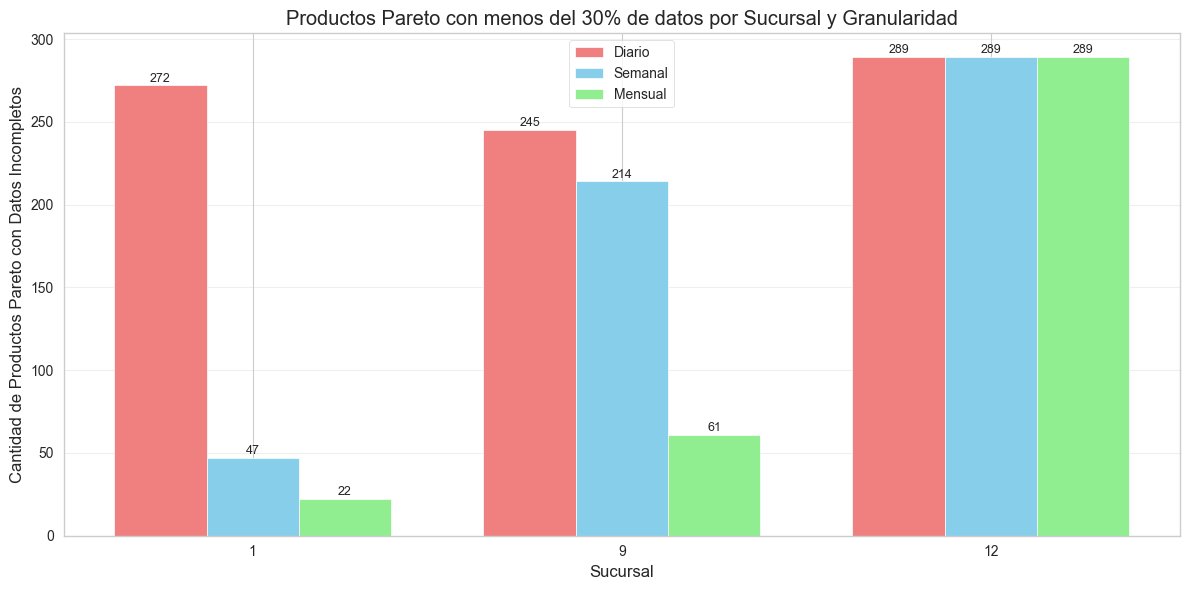


RESUMEN: Productos Mas Vendidos con menos del 30% de datos completos


,Total_Productos_Pareto,Diario,Semanal,Mensual,%_Diario,%_Semanal,%_Mensual
Sucursal,,,,,,,
1,397,272,47,22,68.5,11.8,5.5
9,245,245,214,61,100.0,87.3,24.9
12,289,289,289,289,100.0,100.0,100.0


In [60]:
# PASO 3: Análisis de productos Pareto con datos incompletos por sucursal
def analizar_productos_pareto_incompletos(df, productos_pareto_dict, umbral=0.7):
    """
    Analiza cuántos productos PARETO por sucursal no cumplen con el umbral mínimo de datos
    para cada granularidad temporal (diaria, semanal, mensual)
    """
    idx_diario = pd.date_range(df['fecha'].min(), df['fecha'].max(), freq='D')
    idx_semanal = pd.date_range(df['fecha'].min(), df['fecha'].max(), freq='W')
    idx_mensual = pd.date_range(df['fecha'].min(), df['fecha'].max(), freq='ME')
    
    sucursales = sorted(df['sucur'].unique())
    resultados = []
    
    for sucur in sucursales:
        # Filtrar por sucursal Y productos Pareto
        df_sucur_pareto = df[
            (df['sucur'] == sucur) & 
            (df['descrip'].isin(productos_pareto_dict[sucur]))
        ]
        
        # tablas pivot solo con productos Pareto
        pivot_d = df_sucur_pareto.pivot_table(index='fecha', columns='descrip', values='precio_total', aggfunc='sum').reindex(idx_diario)
        pivot_s = df_sucur_pareto.groupby([pd.Grouper(key='fecha', freq='W'), 'descrip'])['precio_total'].sum().unstack('descrip').reindex(idx_semanal)
        pivot_m = df_sucur_pareto.groupby([pd.Grouper(key='fecha', freq='ME'), 'descrip'])['precio_total'].sum().unstack('descrip').reindex(idx_mensual)
        
        #Calculamos porcentaje de datos completos -dada la granularidad- por producto
        pct_datos_d = (1 - pivot_d.isna().mean()) 
        pct_datos_s = (1 - pivot_s.isna().mean()) 
        pct_datos_m = (1 - pivot_m.isna().mean()) 
        
        # Chequeamos y contamos aquellos productos que no cumplen con el umbral mínimo
        productos_incompletos_d = (pct_datos_d < umbral).sum()
        productos_incompletos_s = (pct_datos_s < umbral).sum()
        productos_incompletos_m = (pct_datos_m < umbral).sum()
        
        total_productos_pareto = len(productos_pareto_dict[sucur])
        
        resultados.append({
            'Sucursal': sucur,
            'Total_Productos_Pareto': total_productos_pareto,
            'Diario': productos_incompletos_d,
            'Semanal': productos_incompletos_s,
            'Mensual': productos_incompletos_m
        })
    
    return pd.DataFrame(resultados)

#####################
## Umbral mínimo de datos completos dada la granularidad temporal (SOLO PRODUCTOS PARETO).
## Abajo encontraremos un gráfico y una tabla que enumeran la cantidad de productos PARETO por sucursal que, 
## dada una granularidad temporal (diaria, semanal, mensual), no llegan al umbral mínimo de datos completos.
umbral = 0.3
df_incompletos_pareto = analizar_productos_pareto_incompletos(df_viz_desc, productos_pareto_dict, umbral)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_incompletos_pareto))
width = 0.25

bars1 = ax.bar(x - width, df_incompletos_pareto['Diario'], width, label='Diario', color='lightcoral')
bars2 = ax.bar(x, df_incompletos_pareto['Semanal'], width, label='Semanal', color='skyblue')
bars3 = ax.bar(x + width, df_incompletos_pareto['Mensual'], width, label='Mensual', color='lightgreen')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Sucursal')
ax.set_ylabel('Cantidad de Productos Pareto con Datos Incompletos')
ax.set_title(f'Productos Pareto con menos del {umbral*100:.0f}% de datos por Sucursal y Granularidad')
ax.set_xticks(x)
ax.set_xticklabels(df_incompletos_pareto['Sucursal'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nRESUMEN: Productos Mas Vendidos con menos del {umbral*100:.0f}% de datos completos")
print("=" * 70)

df_resumen_pareto = df_incompletos_pareto.copy()
df_resumen_pareto['%_Diario'] = (df_resumen_pareto['Diario'] / df_resumen_pareto['Total_Productos_Pareto'] * 100).round(1)
df_resumen_pareto['%_Semanal'] = (df_resumen_pareto['Semanal'] / df_resumen_pareto['Total_Productos_Pareto'] * 100).round(1)
df_resumen_pareto['%_Mensual'] = (df_resumen_pareto['Mensual'] / df_resumen_pareto['Total_Productos_Pareto'] * 100).round(1)

display(df_resumen_pareto.set_index('Sucursal'))

Visualizamos por sucursal en base a los días operativos de las mismas (ya que partimos de la hipotesis de que no todas las sucursales operan desde el mismo periodo de tiempo)


In [61]:
# Calcular rango de fechas por sucursal
fechas_por_sucursal = df_viz_desc.groupby('sucur')['fecha'].agg(['min', 'max'])
fechas_por_sucursal['dias_totales'] = (fechas_por_sucursal['max'] - fechas_por_sucursal['min']).dt.days + 1
# Calcular días con datos por sucursal
dias_con_datos = df_viz_desc.groupby('sucur')['fecha'].nunique().rename('dias_con_datos')
# Unir ambos
fechas_por_sucursal = fechas_por_sucursal.join(dias_con_datos)
fechas_por_sucursal['porcentaje_dias_con_datos'] = 100 * fechas_por_sucursal['dias_con_datos'] / fechas_por_sucursal['dias_totales']
# Mostrar resultado ordenado
fechas_por_sucursal = fechas_por_sucursal.sort_values('min')
display(fechas_por_sucursal)

,min,max,dias_totales,dias_con_datos,porcentaje_dias_con_datos
sucur,,,,,
1,2022-01-03,2024-02-29,788,644,81.725888
9,2022-01-08,2024-06-29,904,394,43.584071
12,2024-03-01,2024-06-29,121,98,80.991736


### 1.3 Analis de Valores Faltantes en Ventas POR CLIENTE

¿Qué analisis haremos?
Ver el Promedio de porcentaje de faltantes en productos mas vendidos para cada cliente (segun cada granularidad)

In [62]:
# 1. Determinar los clientes que representan el 80% de la frecuencia de compras
frecuencia_clientes = df_viz_desc['cliente'].value_counts()
frecuencia_acum = frecuencia_clientes.cumsum()
pct_acum = frecuencia_acum / frecuencia_clientes.sum() * 100

clientes_top_80 = frecuencia_acum[pct_acum <= 80].index.tolist()

# 2. Identificar productos Pareto (por frecuencia) por cliente — SOLO para clientes del 80%
productos_pareto_frecuencia_cliente = {}

for cliente in clientes_top_80:
    df_cli = df_viz_desc[df_viz_desc['cliente'] == cliente]
    
    frecuencia = df_cli['descrip'].value_counts()
    frecuencia_acum = frecuencia.cumsum()
    pct_acum = frecuencia_acum / frecuencia.sum() * 100
    
    productos_pareto = frecuencia[pct_acum <= 80].index.tolist()
    productos_pareto_frecuencia_cliente[cliente] = productos_pareto

# 3. Crear índices por granularidad
idx_d = pd.date_range(df_viz_desc['fecha'].min(), df_viz_desc['fecha'].max(), freq='D')
idx_w = pd.date_range(df_viz_desc['fecha'].min(), df_viz_desc['fecha'].max(), freq='W')
idx_m = pd.date_range(df_viz_desc['fecha'].min(), df_viz_desc['fecha'].max(), freq='ME')

resultados = []

# 4. Calcular porcentaje promedio de faltantes solo para los clientes del 80%
for cliente in clientes_top_80:
    productos_pareto = productos_pareto_frecuencia_cliente[cliente]
    if not productos_pareto:
        continue

    df_cli = df_viz_desc[
        (df_viz_desc['cliente'] == cliente) &
        (df_viz_desc['descrip'].isin(productos_pareto))
    ]

    # Pivot por granularidad
    pivot_d = df_cli.pivot_table(index='fecha', columns='descrip', values='precio_total', aggfunc='sum').reindex(idx_d)
    pivot_w = df_cli.groupby([pd.Grouper(key='fecha', freq='W'), 'descrip'])['precio_total'].sum().unstack('descrip').reindex(idx_w)
    pivot_m = df_cli.groupby([pd.Grouper(key='fecha', freq='ME'), 'descrip'])['precio_total'].sum().unstack('descrip').reindex(idx_m)

    # Porcentaje promedio de faltantes entre los productos Pareto
    falt_d = pivot_d.isna().mean().mean() * 100
    falt_w = pivot_w.isna().mean().mean() * 100
    falt_m = pivot_m.isna().mean().mean() * 100

    resultados.append({
        'cliente': cliente,
        'falt_pct_diario': falt_d,
        'falt_pct_semanal': falt_w,
        'falt_pct_mensual': falt_m
    })

# 5. Crear DataFrame de resultados
df_faltantes_prom = pd.DataFrame(resultados)

# 6. Mostrar promedio de faltantes entre los clientes que representan el 80% de la frecuencia
promedios = df_faltantes_prom[['falt_pct_diario', 'falt_pct_semanal', 'falt_pct_mensual']].mean().round(1)

print("Promedio de porcentaje de faltantes en productos más vendidos para clientes que representan el 80% de la frecuencia:")
print(promedios)

Promedio de porcentaje de faltantes en productos más vendidos para clientes que representan el 80% de la frecuencia:
falt_pct_diario     98.9
falt_pct_semanal    92.6
falt_pct_mensual    75.0
dtype: float64


Conclusión: En promedio, cada cliente del top 80% por frecuencia tiene un 75% de valores faltantes entre sus productos más comprados (según frecuencia), al agrupar los datos de forma mensual.

### Elección y Justificacion

Vamos a elegir una granularidad MENSUAL

Esto dado a:
- es la granularidad con mejor calidad de datos en termino de las ausencias de los mismos (Tanto para una mirada global como para los más vendidos)
- nuestro negocio esta muy "cerca" del consumidor final  ya que son productos de consumo y aunque a lo sumo serán comprados por un revendedor podemos decir que el mes es una buena medida para el consumo de nuestros productos
- está alineado con la toma de decisiones del negocio: las decisiones estratégicas (como planificacion de stock, evaluacion de performance y proyecciones de ingresos) se toman por lo menos con esta periodicidad
- menos sensibilidad a eventos esporádicos como picos por promociones, caidas de las ventas por feriados o problemas de facturación

### 1.4 Depuración y transformación del dataset


In [63]:
# Generamos dataset agregado con valores por unidad de análisis
df_base = df_viz_desc.copy()
#df_base= df_pareto.copy() ###########Ver si hacemos de los productos del pareto##########

# columnas a conservar para el resto de los ejercicios
cols_min = [
    'cliente', 'produc', 'descrip', # cvan a ser nuestras keys
    'depo', 'tipo_negocio', 'lista_precios',# contexto del PDV
    'condi_venta', 'vende', 'linea_nume', # capaz sacar esto, es por vendedor
    'fecha', 'canti', 'precio_total', # métricas (ver si hay alguna otra para agregar)
]
df_base = df_base[cols_min]   

#agregado mensual
df_base['mes'] = df_base['fecha'].dt.to_period('M')

# agregamos por cliente,sku y mes
agg_mensual = (df_base
               .groupby(['cliente', 'produc', 'mes'], sort=False)
               .agg(
                   ventas_totales   = ('precio_total', 'sum'),
                   unidades_totales = ('canti',  'sum'),
                   dias_con_venta   = ('fecha',        lambda x: x.dt.normalize().nunique())
               )
               .reset_index())

#frecuencia relativa dentro del mes
agg_mensual['dias_mes']       = agg_mensual['mes'].dt.days_in_month
agg_mensual['frecuencia_pct'] = agg_mensual['dias_con_venta'] / agg_mensual['dias_mes']


#unimos col que no cambian con la agregacion
meta_cols = [
    'cliente', 'produc', 'descrip',
    'depo', 'tipo_negocio', 'lista_precios', 'condi_venta', 'vende', 'linea_nume'
]
agg_mensual = (
    agg_mensual
    .merge(df_base.drop_duplicates(['cliente','produc'])[meta_cols],
           on=['cliente','produc'],
           how='left')
)

display(agg_mensual.head())
display(agg_mensual.info())



,cliente,produc,mes,ventas_totales,unidades_totales,dias_con_venta,dias_mes,frecuencia_pct,descrip,depo,tipo_negocio,lista_precios,condi_venta,vende,linea_nume
0,4627,000-999-202201370,2022-01,115.877378,2.0,1,31,0.032258,turron arcor,NaN,1.0,2,00,1.0,2
1,4627,000-000-6614,2022-01,58.464301,12.0,2,31,0.064516,pure tomate arcor x 520,1.0,1.0,2,00,1.0,1
2,4627,000-000-3777,2022-01,15.022565,6.0,1,31,0.032258,criollitas original x 100 grs.,1.0,1.0,2,00,1.0,4
3,4627,000-000-10204,2022-01,22.343718,9.0,1,31,0.032258,criollitas x 300 grs,1.0,1.0,2,00,1.0,5
4,4627,000-000-1060,2022-01,54.378356,125.0,1,31,0.032258,choco-mani x 120 uds.,1.0,1.0,2,00,1.0,27


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241388 entries, 0 to 241387
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype    
---  ------            --------------   -----    
 0   cliente           241388 non-null  int64    
 1   produc            241388 non-null  object   
 2   mes               241388 non-null  period[M]
 3   ventas_totales    241388 non-null  float64  
 4   unidades_totales  241388 non-null  float64  
 5   dias_con_venta    241388 non-null  int64    
 6   dias_mes          241388 non-null  int64    
 7   frecuencia_pct    241388 non-null  float64  
 8   descrip           241388 non-null  object   
 9   depo              195781 non-null  float64  
 10  tipo_negocio      241348 non-null  float64  
 11  lista_precios     241388 non-null  int64    
 12  condi_venta       241388 non-null  object   
 13  vende             241348 non-null  float64  
 14  linea_nume        241388 non-null  int64    
dtypes: float64(6), int64(5), object(3)

None

In [64]:
# % meses faltantes POR PRODUCTO (SKU) 
df_agg_mensual = agg_mensual.copy()

total_meses_pareto = df_agg_mensual['mes'].nunique()

sku_cov = (
    df_agg_mensual
      .groupby('produc')['mes']
      .nunique()                           # cuántos meses tiene al menos 1 venta
      .reset_index(name='meses_presentes')
)

sku_cov['pct_missing_prod'] = (
    (total_meses_pareto - sku_cov['meses_presentes']) / total_meses_pareto * 100
)

# agregamos descripción para que sea legible
sku_cov = sku_cov.merge(
    df_agg_mensual[['produc','descrip']].drop_duplicates(),
    on='produc',
    how='left'
)

# ordenamos del más completo (menos % faltante) al más hueco
sku_cov_sorted = sku_cov.sort_values('pct_missing_prod')

display(sku_cov_sorted.head(20))     


,produc,meses_presentes,pct_missing_prod,descrip
16,000-000-10129,30,0.0,mentho plus cherry x 12 uds.
15,000-000-10128,30,0.0,mentho plus menthol x 12 uds.
91,000-000-11090,30,0.0,mentho plus acido manzana x 12 uds.
103,000-000-11283,30,0.0,cofler block x 110 grs.
921,000-000-1693,30,0.0,mogul cerebrito x 12 uds
922,000-000-1732,30,0.0,kesitas estuche x 125 grs.
923,000-000-1782,30,0.0,masticable frutal x 800 grs.
444,000-000-13185,30,0.0,jg. pv. bc pomelo rosado x 18 uds.
414,000-000-13151,30,0.0,merm. bc durazno x 390 grs.
416,000-000-13153,30,0.0,merm. bc frutilla x 390 grs.


In [65]:
total_meses = df_agg_mensual['mes'].nunique()

# armamos los rangos o bins
bins  = np.arange(0, 110, 10)          # 0-10, 10-20, … 90-100
labels = [f'{i}-{i+10}%' for i in bins[:-1]]
sku_cov['rango_pct'] = pd.cut(
    sku_cov['pct_missing_prod'],
    bins=bins,
    labels=labels,
    right=True,                      
    include_lowest=True
)

tabla_rangos = (
    sku_cov.groupby('rango_pct')
           .agg(
               skus_count     = ('produc', 'nunique'),
               meses_falt_tot = ( 'pct_missing_prod',
                                  lambda x: int(np.round((x/100*total_meses).sum())) )
           )
           .reset_index()
)
print(df_agg_mensual['mes'].min(), df_agg_mensual['mes'].max())
display(tabla_rangos)


2022-01 2024-06


C:\Users\marti\AppData\Local\Temp\ipykernel_16564\2412293384.py:15: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,rango_pct,skus_count,meses_falt_tot
0,0-10%,312,301
1,10-20%,70,368
2,20-30%,80,664
3,30-40%,69,782
4,40-50%,57,830
5,50-60%,46,825
6,60-70%,87,1766
7,70-80%,104,2443
8,80-90%,1032,27545
9,90-100%,5671,162983


De lo anterior se desprende que:


- **312 productos (~4 %)** presentan series prácticamente completas (≤ 10 % de meses faltantes).
- **462 productos (~6 %)** cumplen el umbral de “aceptable” (≤ 30 % de faltantes, es decir ≥ 70 % de cobertura).
- **1395 productos (~19 %)** quedan fuera de ese estándar, pero sin llegar al extremo de muy escasos datos (30-90 % de faltantes).
- **5671 productos (~75 %)** tienen datos extremadamente escasos (90-100 % de meses faltantes), por lo que no resultan útiles para análisis temporales.





**DISCLAIMER**: Estos umbrales registran la falta mensual de productos a nivel **GLOBAL**, no por PDV (cliente). 


Si nos guiamos por estos umbrales para filtrar el dataset, podemos llegar a eliminar productos que son críticos para clientes específicos: Un producto puede tener 70% de faltantes globales pero ser el producto principal de un cliente específico.


**Estrategias Alternativas**

Filtrado por cliente-producto: Conservar productos que representen >X% de las ventas de cada cliente

Hacemos el mismo análisis pero ahora por cliente y producto

In [66]:
# Total de meses en el dataset (horizonte común)
total_meses = df_agg_mensual['mes'].nunique()

# Cobertura por combinación cliente + producto
cli_sku_cov = (
    df_agg_mensual
      .groupby(['cliente', 'produc'])['mes']
      .nunique()  # cuántos meses tiene esa combinación
      .reset_index(name='meses_presentes')
)

cli_sku_cov['pct_missing_cli_prod'] = (
    (total_meses - cli_sku_cov['meses_presentes']) / total_meses * 100
)

# Añadimos descripción del producto para mejor lectura
cli_sku_cov = cli_sku_cov.merge(
    df_agg_mensual[['cliente', 'produc', 'descrip']].drop_duplicates(),
    on=['cliente', 'produc'],
    how='left'
)

# Ordenamos del más completo al más hueco
cli_sku_cov_sorted = cli_sku_cov.sort_values('pct_missing_cli_prod')

display(cli_sku_cov_sorted.head(20))


,cliente,produc,meses_presentes,pct_missing_cli_prod,descrip
91919,27677,000-000-13151,30,0.000000,merm. bc durazno x 390 grs.
91905,27677,000-000-12625,30,0.000000,cereal mix light yog/frut x 20 uds.
91946,27677,000-000-13349,30,0.000000,macucas x 110 grs.
52250,6294,000-000-11283,30,0.000000,cofler block x 110 grs.
32619,4902,000-000-9341,30,0.000000,opera x 92 grs.
21420,3922,000-000-9341,30,0.000000,opera x 92 grs.
85291,9093,000-000-13349,29,3.333333,macucas x 110 grs.
89576,9743,000-000-1732,29,3.333333,kesitas estuche x 125 grs.
81662,8257,000-000-10174,29,3.333333,rex x 75 grs.
52398,6294,000-000-6140,29,3.333333,alf. bon o bon triple x 60 grs


In [67]:
# Armamos bins de 0-10%, 10-20%, … 90-100%
bins_cli  = np.arange(0, 110, 10)
labels_cli = [f'{i}-{i+10}%' for i in bins_cli[:-1]]

cli_sku_cov['rango_pct'] = pd.cut(
    cli_sku_cov['pct_missing_cli_prod'],
    bins=bins_cli,
    labels=labels_cli,
    right=True,
    include_lowest=True
)

tabla_rangos_cli_prod = (
    cli_sku_cov
      .groupby('rango_pct')
      .agg(
          cliente_prod_count = ('produc', 'count'),  # cantidad de combinaciones
          meses_falt_tot     = ('pct_missing_cli_prod',
                                lambda x: int(np.round((x/100 * total_meses).sum())))
      )
      .reset_index()
)

print(df_agg_mensual['mes'].min(), df_agg_mensual['mes'].max())
display(tabla_rangos_cli_prod)


2022-01 2024-06


C:\Users\marti\AppData\Local\Temp\ipykernel_16564\2522616443.py:15: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,rango_pct,cliente_prod_count,meses_falt_tot
0,0-10%,77,177
1,10-20%,231,1203
2,20-30%,394,3197
3,30-40%,632,7000
4,40-50%,1066,15002
5,50-60%,1526,26063
6,60-70%,2387,48030
7,70-80%,4527,104781
8,80-90%,10233,268589
9,90-100%,72521,2092390


De lo anterior se desprende que:


-**77 combinaciones (≈0,1 %)** poseen una serie prácticamente completa, con menos del 10 % de meses sin datos.

-**702 combinaciones (≈0,8 %)** alcanzan el umbral “aceptable” de cobertura (al menos el 70 % de los meses disponibles).

-**20371 combinaciones (≈21,8 %)** quedan fuera de ese estándar: tienen más del 30 % y menos del 90 % de faltantes.

-**72521 combinaciones (≈77,5 %)** presentan datos extremadamente escasos (90-100 % de meses faltantes) y resultan poco útiles para análisis temporales.

## 2. Depuración de Datos

### 2.1 Análisis de Datos Faltantes: Caso de filtrado por umbral x cada PDV 

1. **Filtrar productos en cada PDV** con más del 30% de datos faltantes a nivel local (en ese PDV).
2. **Imputar** los valores faltantes de aquellos productos que se ubiquen por debajo del umbral del 30% de daatos faltantes.

In [68]:
###############GENERAR FILTRO EN BASE A CLIENTES-PRODUCTOS? UMBRAL 70%?#####################
total_meses = df_agg_mensual["mes"].nunique()         # horizonte total
ultimo_mes  = df_agg_mensual["mes"].max()             # último mes del dataset
ultimos_12  = pd.period_range(end=ultimo_mes, periods=12, freq="M")  # PeriodIndex

# cobertura por cliente-producto 
serie_meses = (df_agg_mensual.groupby(["cliente", "produc"])["mes"].agg(lista_meses=list,n_meses="nunique").reset_index())

# etiquetamos
# aceptambles para >=70 % de cobertura
serie_meses["aceptable"] = serie_meses["n_meses"] >= 0.7 * total_meses


# “posible” para ≥12 meses *y* cubre los 12 últimos meses del dataset (definido arbitrariamente discutir de vueta esto)
def cubre_ultimos_12(meses):
    meses_per = pd.Series(meses).astype("period[M]")
    return set(ultimos_12).issubset(set(meses_per))

serie_meses["posible"] = (
    (~serie_meses["aceptable"]) &                 # NO cumple 70 %
    (serie_meses["n_meses"] >= 24) &              # ≥24 meses en total (cualquier cosa cambiamos)
    (serie_meses["lista_meses"].apply(cubre_ultimos_12))  # cubre últimos 12
)

# ≥70% de meses AND cubre últimos 12 meses (nos quedan 60 productos solamente, no aplicar)
# serie_meses["aceptable"] = (
#     (serie_meses["n_meses"] >= 0.7 * total_meses) &
#     (serie_meses["lista_meses"].apply(cubre_ultimos_12))
# )

total_cp      = len(serie_meses)
n_70pct       = serie_meses["aceptable"].sum()
n_posibles    = serie_meses["posible"].sum()
n_resto       = total_cp - n_70pct - n_posibles

print(f"Total cliente-producto      : {total_cp}")
print(f"Aceptables (≥70 % meses)    : {n_70pct} ({n_70pct/total_cp:.2%})")
print(f"Posibles (≥12 y últimos 12) : {n_posibles} ({n_posibles/total_cp:.2%})")
print(f"Resto                       : {n_resto} ({n_resto/total_cp:.2%})")


# GENERAR CONDICION PARA ACEPTABLE

Total cliente-producto      : 93594
Aceptables (≥70 % meses)    : 702 (0.75%)
Posibles (≥12 y últimos 12) : 0 (0.00%)
Resto                       : 92892 (99.25%)


In [69]:
condiciones_aceptable = serie_meses[serie_meses["aceptable"]]

df_aceptable = df_agg_mensual.merge(condiciones_aceptable[["cliente", "produc"]],on=["cliente", "produc"],how="inner")

df_aceptable.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16483 entries, 0 to 16482
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype    
---  ------            --------------  -----    
 0   cliente           16483 non-null  int64    
 1   produc            16483 non-null  object   
 2   mes               16483 non-null  period[M]
 3   ventas_totales    16483 non-null  float64  
 4   unidades_totales  16483 non-null  float64  
 5   dias_con_venta    16483 non-null  int64    
 6   dias_mes          16483 non-null  int64    
 7   frecuencia_pct    16483 non-null  float64  
 8   descrip           16483 non-null  object   
 9   depo              16461 non-null  float64  
 10  tipo_negocio      16483 non-null  float64  
 11  lista_precios     16483 non-null  int64    
 12  condi_venta       16483 non-null  object   
 13  vende             16483 non-null  float64  
 14  linea_nume        16483 non-null  int64    
dtypes: float64(6), int64(5), object(3), period[M](1)
memo

In [70]:
relaciones_validas = df_aceptable[['cliente', 'produc']].drop_duplicates()

# Meses disponibles (todos los del horizonte temporal)
meses = df_aceptable['mes'].sort_values().unique()

# Generamos todas las combinaciones cliente-producto con cada mes
completo = (
    relaciones_validas
    .assign(key=1)
    .merge(pd.DataFrame({'mes': meses, 'key': 1}), on='key')
    .drop('key', axis=1)
)

completo.info()
completo.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21060 entries, 0 to 21059
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype    
---  ------   --------------  -----    
 0   cliente  21060 non-null  int64    
 1   produc   21060 non-null  object   
 2   mes      21060 non-null  period[M]
dtypes: int64(1), object(1), period[M](1)
memory usage: 493.7+ KB


,cliente,produc,mes
0,4627,000-000-2001,2022-01
1,4627,000-000-2001,2022-02
2,4627,000-000-2001,2022-03
3,4627,000-000-2001,2022-04
4,4627,000-000-2001,2022-05


In [71]:
df_final = completo.merge(df_aceptable, on=['cliente', 'produc', 'mes'], how='left')

In [72]:
print("Filas con datos válidos (no NaN):")
print(f"ventas_totales no NaN: {df_final['ventas_totales'].notna().sum()}")
print(f"Total filas: {len(df_final)}")
print(f"Porcentaje con ventas: {df_final['ventas_totales'].notna().mean():.2%}")

Filas con datos válidos (no NaN):
ventas_totales no NaN: 16483
Total filas: 21060
Porcentaje con ventas: 78.27%


In [73]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21060 entries, 0 to 21059
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype    
---  ------            --------------  -----    
 0   cliente           21060 non-null  int64    
 1   produc            21060 non-null  object   
 2   mes               21060 non-null  period[M]
 3   ventas_totales    16483 non-null  float64  
 4   unidades_totales  16483 non-null  float64  
 5   dias_con_venta    16483 non-null  float64  
 6   dias_mes          16483 non-null  float64  
 7   frecuencia_pct    16483 non-null  float64  
 8   descrip           16483 non-null  object   
 9   depo              16461 non-null  float64  
 10  tipo_negocio      16483 non-null  float64  
 11  lista_precios     16483 non-null  float64  
 12  condi_venta       16483 non-null  object   
 13  vende             16483 non-null  float64  
 14  linea_nume        16483 non-null  float64  
dtypes: float64(10), int64(1), object(3), period[M](1)
mem

In [74]:
df_final.head()

,cliente,produc,mes,ventas_totales,unidades_totales,dias_con_venta,dias_mes,frecuencia_pct,descrip,depo,tipo_negocio,lista_precios,condi_venta,vende,linea_nume
0,4627,000-000-2001,2022-01,22.727986,12.0,1.0,31.0,0.032258,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0
1,4627,000-000-2001,2022-02,48.113674,24.0,2.0,28.0,0.071429,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0
2,4627,000-000-2001,2022-03,80.252343,36.0,3.0,31.0,0.096774,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0
3,4627,000-000-2001,2022-04,30.300890,12.0,1.0,30.0,0.033333,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0
4,4627,000-000-2001,2022-05,68.505820,24.0,2.0,31.0,0.064516,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0


In [75]:
meses_unicos = df_final['mes'].unique()
print(f"Meses únicos: {total_meses} ({meses_unicos[0].strftime('%Y-%m')} a {meses_unicos[-1].strftime('%Y-%m')})")


productos_por_cliente = df_final.groupby('cliente')['produc'].nunique()


df_final['sin_venta'] = df_final['ventas_totales'].isna()

# Contamos meses sin venta por cliente–producto
meses_sin_venta_cp = df_final.groupby(['cliente', 'produc'])['sin_venta'].sum().reset_index()


# Volvemos a calcular promedio de meses sin venta por producto por cliente
promedio_faltantes_cliente = meses_sin_venta_cp.groupby('cliente')['sin_venta'].mean()


resumen = pd.DataFrame({
    'productos_diferentes': productos_por_cliente,
    'promedio_meses_faltantes': promedio_faltantes_cliente
}).sort_values(by='productos_diferentes', ascending=False)

print(resumen.head())



Meses únicos: 30 (2022-01 a 2024-06)
         productos_diferentes  promedio_meses_faltantes
cliente                                                
9546                       23                  6.695652
9743                       22                  5.272727
6294                       20                  5.550000
4943                       19                  6.736842
526                        19                  5.842105


### 2.2 Imputación de valores faltantes


#### Técnicas de Imputación – Descripción y Requisitos

---



#### 🔹 `forward_fill`
- **Qué hace**: Rellena valores faltantes con el último valor válido anterior.
- **Cómo funciona**: Avanza fila por fila y copia el valor anterior si el actual es `NaN`.
- **Ejemplo**: `[NaN, 5, NaN, NaN, 8] → [NaN, 5, 5, 5, 8]`
- **Límite**: No puede imputar si la serie empieza con `NaN`.
- **Requiere**:
  - Ordenar por `cliente`, `produc` y `mes`.
  - No necesita fechas reales (`mes` como datetime es opcional).
- **Ideal para**: Series donde el último valor es una buena aproximación del siguiente.

---

#### 🔹 `rolling_mean`
- **Qué hace**: Imputa usando el promedio móvil de las últimas `n` observaciones.
- **Cómo funciona**: Calcula la media de una ventana (ej. 3 meses) hacia atrás dentro del grupo.
- **Ejemplo**: `[NaN, 3, 6, NaN] → [NaN, 3, 6, 4.5]`
- **Límite**: No funciona bien si hay muchos `NaN` seguidos o al principio.
- **Requiere**:
  - Ordenar por `cliente`, `produc` y `mes`. (Ver el caso en el que salta de un producto a otro)
  - No necesita convertir `mes` a datetime.
- **Ideal para**: Series con fluctuaciones suaves y suficientes valores históricos.

---

#### 🔹 `interpolacion` (lineal)
- **Qué hace**: Rellena valores faltantes trazando una línea recta entre puntos válidos.
- **Cómo funciona**: Busca dos puntos válidos antes y después del `NaN` y estima el valor en el medio.
- **Ejemplo**: `[2, NaN, NaN, 8] → [2, 4, 6, 8]`
- **Límite**: No funciona si solo hay un punto válido, o si el `NaN` está al inicio o al final.
- **Requiere**:
  - Ordenar por `cliente`, `produc` y `mes`.
  - Para respetar dimensión temporal real, convertir `mes` a datetime y usar `method='time'`.
- **Ideal para**: Series con tendencias lineales suaves y sin demasiados faltantes extremos.

---

#### 🔹 `fill_zero`
- **Qué hace**: Reemplaza directamente todos los `NaN` por 0.
- **Cómo funciona**: Asume que valor faltante significa “no venta”.
- **Ejemplo**: `[NaN, 3, NaN] → [0, 3, 0]`
- **Límite**: Puede ocultar faltantes reales o errores de carga.
- **Requiere**: Nada adicional.
- **Ideal para**: Casos donde el negocio define explícitamente que ausencia = 0 ventas.


#### Función de imputación

In [76]:
#Función para imputar series temporales según técnica seleccionada

def imputar_series(df, columna_objetivo, tecnica='forward_fill'):

    df = df.sort_values(by=['cliente', 'produc', 'mes']).copy()
    
    if tecnica == 'forward_fill':
        df[columna_objetivo] = df.groupby(['cliente', 'produc'])[columna_objetivo].ffill()

    elif tecnica == 'fill_zero':
        df[columna_objetivo] = df.groupby(['cliente', 'produc'])[columna_objetivo].transform(lambda x: x.fillna(0))
    
    elif tecnica == 'rolling_mean':
        df[columna_objetivo] = df.groupby(['cliente', 'produc'])[columna_objetivo]\
                                 .transform(lambda x: x.fillna(x.rolling(window=3, min_periods=1).mean()))
    
    elif tecnica == 'interpolacion':
        df[columna_objetivo] = df.groupby(['cliente', 'produc'])[columna_objetivo].transform(lambda x: x.interpolate(method='linear'))
    
    else:
        print("Técnica no válida")
    
    return df


In [77]:
# df_final_ffill = imputar_series(df_final.copy(), 'ventas_totales', 'forward_fill')
df_final_fill_zero = imputar_series(df_final.copy(), 'ventas_totales', 'fill_zero')
# df_final_rolling_mean = imputar_series(df_final.copy(), 'ventas_totales', 'rolling_mean')
# df_final_interpolacion = imputar_series(df_final.copy(), 'ventas_totales', 'interpolacion')

In [78]:
df_final_fill_zero.head()
#Para clusterización podríamos agregar tipo de factura (mayorista vs minorista) ¿Qué otras columnas podríamos agregar?

,cliente,produc,mes,ventas_totales,unidades_totales,dias_con_venta,dias_mes,frecuencia_pct,descrip,depo,tipo_negocio,lista_precios,condi_venta,vende,linea_nume,sin_venta
19740,296,000-000-3313,2022-01,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
19741,296,000-000-3313,2022-02,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
19742,296,000-000-3313,2022-03,203.268027,84.0,2.0,31.0,0.064516,alf. tatin blanco x 33 gr.,1.0,1.0,3.0,00,2.0,18.0,False
19743,296,000-000-3313,2022-04,155.282037,56.0,1.0,30.0,0.033333,alf. tatin blanco x 33 gr.,1.0,1.0,3.0,00,2.0,18.0,False
19744,296,000-000-3313,2022-05,81.256412,28.0,1.0,31.0,0.032258,alf. tatin blanco x 33 gr.,1.0,1.0,3.0,00,2.0,18.0,False


In [79]:
print("Cantidad de NaN en DF original: ", df_final["ventas_totales"].isna().sum())
# print("Cantidad de NaN en DF con forward fill: ", df_final_ffill["ventas_totales"].isna().sum())
print("Cantidad de NaN en DF con fill zero: ", df_final_fill_zero["ventas_totales"].isna().sum())
# print("Cantidad de NaN en DF con rolling mean: ", df_final_rolling_mean["ventas_totales"].isna().sum())
# print("Cantidad de NaN en DF con interpolación: ", df_final_interpolacion["ventas_totales"].isna().sum())

Cantidad de NaN en DF original:  4577
Cantidad de NaN en DF con fill zero:  0


## 3. Escalado/Normalización


In [80]:
#Escalar canti 
from sklearn.preprocessing import StandardScaler, MinMaxScaler

def escalar_columnas(df, columnas, tecnica='standard'):
    df = df.copy()

    if tecnica == 'standard':
        scaler = StandardScaler()
    elif tecnica == 'minmax':
        scaler = MinMaxScaler()
    else:
        raise ValueError("Técnica no válida. Usar: 'standard' o 'minmax'.")

    df[columnas] = scaler.fit_transform(df[columnas])
    
    return df


In [81]:
columnas_a_escalar = ['ventas_totales', 'unidades_totales']
df_scaled = escalar_columnas(df_final, columnas_a_escalar, tecnica='standard')
df_scaled.head()

,cliente,produc,mes,ventas_totales,unidades_totales,dias_con_venta,dias_mes,frecuencia_pct,descrip,depo,tipo_negocio,lista_precios,condi_venta,vende,linea_nume,sin_venta
0,4627,000-000-2001,2022-01,-0.441526,-0.221559,1.0,31.0,0.032258,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False
1,4627,000-000-2001,2022-02,-0.431416,-0.147969,2.0,28.0,0.071429,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False
2,4627,000-000-2001,2022-03,-0.418617,-0.074380,3.0,31.0,0.096774,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False
3,4627,000-000-2001,2022-04,-0.438510,-0.221559,1.0,30.0,0.033333,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False
4,4627,000-000-2001,2022-05,-0.423295,-0.147969,2.0,31.0,0.064516,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False


## 4. Guardado de Dataset

In [89]:
df_scaled.to_csv('../data/final_cured_df.csv')

#### Elección y Justificación
Vamos a elegir **StandarScaler** pues necesitamos estandarizar nuestras variables numéricas con el objetivo de realizar la **Segmentación de Clientes** y en este sentido este algoritmo se destaca sobre MinMaxScaler (normalización) pues:
1. Preserva la estructura natural de los datos.
2. Maneja mejor los outliers
3. Es más compatible con los algoritmos que usaremos: K-Means, DBSCAN o Gaussian Mixture Models -> *esto se debe a que la mayoria de estos algoritmos tiene en cuenta la distancia entre clientes, cosa que se preserva mejor con Estandarización.*